### Student Information
Name: 張家榕

Student ID: 110020036

GitHub ID: chiajungchang2003

---

### Instructions

### First Phase Submission

1. First: do the **take home** exercises in the [DM2025-Lab1-Master](https://github.com/leoson-wu/DM2025-Lab1-Exercise/blob/main/DM2025-Lab1-Master.ipynb) that considered as **phase 1 (from exercise 1 to exercise 15)**. You can answer in the master file. __This part is worth 10% of your grade.__


2. Second: follow the same process from the [DM2025-Lab1-Master](https://github.com/leoson-wu/DM2025-Lab1-Exercise/blob/main/DM2025-Lab1-Master.ipynb) on **the new dataset** up **until phase 1**. You can skip some exercises if you think some steps are not necessary. However main exercises should be completed. You don't need to explain all details as we did (some **minimal comments** explaining your code are useful though).  __This part is worth 15% of your grade.__
    -  Use [the new dataset](https://github.com/leoson-wu/DM2025-Lab1-Exercise/blob/main/newdataset/Reddit-stock-sentiment.csv). The dataset contains a 16 columns including 'text' and 'label', with the sentiment labels being: 1.0 is positive, 0.0 is neutral and -1.0 is negative. You can simplify the dataset and use only the columns that you think are necessary. 
    
    - You are allowed to use and modify the `helper` functions in the folder of the first lab session (notice they may need modification) or create your own.
    - Use this file to complete the homework from the second part. Make sure the code can be run from the beginning till the end and has all the needed output.


3. Third: please attempt the following tasks on **the new dataset**. __This part is worth 10% of your grade.__
    - Generate meaningful **new data visualizations**. Refer to online resources and the Data Mining textbook for inspiration and ideas. 
    


4. Fourth: It's hard for us to follow if your code is messy, so please **tidy up your notebook** and **add minimal comments where needed**. __This part is worth 5% of your grade.__

You can submit your homework following these guidelines: [DM2025-Lab1-announcement](https://github.com/leoson-wu/DM2025-Lab1-Announcement/blob/main/README.md). Make sure to commit and save your changes to your repository __BEFORE the deadline (September 28th 11:59 pm, Sunday)__. 

### Second Phase Submission 

**You can keep the answer for phase 1 for easier running and update the phase 2 on the same page.**

1. First: Continue doing the **take home** exercises in the [DM2025-Lab1-Master](https://github.com/leoson-wu/DM2025-Lab1-Exercise/blob/main/DM2025-Lab1-Master.ipynb) for **phase 2, starting from Finding frequent patterns**. Use the same master(.ipynb) file. Answer from phase 1 will not be considered at this stage. You can answer in the master file. __This part is worth 10% of your grade.__


2. Second: Continue from first phase and do the same process from the [DM2025-Lab1-Master](https://github.com/leoson-wu/DM2025-Lab1-Exercise/blob/main/DM2025-Lab1-Master.ipynb) on **the new dataset** for phase 2, starting from Finding frequent pattern. You can skip some exercises if you think some steps are not necessary. However main exercises should be completed. You don't need to explain all details as we did (some **minimal comments** explaining your code are useful though).  __This part is worth 15% of your grade.__
    - Continue using this file to complete the homework from the second part. Make sure the code can be run from the beginning till the end and has all the needed output. Use the same new dataset as in phase 1.
    
    - You are allowed to use and modify the `helper` functions in the folder of the first lab session (notice they may need modification) or create your own.

3. Third: please attempt the following tasks on **the new dataset**. __This part is worth 20% of your grade.__
    - Use this file to answer.
    - Generate **TF-IDF features** from the tokens of each text. This will generating a document matrix, however, the weights will be computed differently (using the TF-IDF value of each word per document as opposed to the word frequency).  Refer to this Scikit-learn [guide](http://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfVectorizer.html) .
    - Implement a simple **Naive Bayes classifier** that automatically classifies the records into their categories. Use both the TF-IDF features and word frequency features to build two seperate classifiers. Note that for the TF-IDF features you might need to use other type of NB classifier different than the one in the Master Notebook. Comment on the differences and when using augmentation with feature pattern.  Refer to this [article](https://hub.packtpub.com/implementing-3-naive-bayes-classifiers-in-scikit-learn/).


4. Fourth: In the lab, we applied each step really quickly just to illustrate how to work with your dataset. There are somethings that are not ideal or the most efficient/meaningful. Each dataset can be handled differently as well. What are those inefficent parts you noticed? How can you improve the Data preprocessing for these specific datasets? __This part is worth 10% of your grade.__


5. Fifth: It's hard for us to follow if your code is messy, so please **tidy up your notebook** and **add minimal comments where needed**. __This part is worth 5% of your grade.__


You can submit your homework following these guidelines: [DM2025-Lab1-announcement](https://github.com/leoson-wu/DM2025-Lab1-Announcement/blob/main/README.md). Make sure to commit and save your changes to your repository __BEFORE the deadline (October 19th 11:59 pm, Sunday)__. 

# Phase 1

In [10]:
!pip install wordcloud

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


Shape: (847, 16)
Columns: Index(['type', 'datetime', 'post_id', 'subreddit', 'title', 'author', 'url',
       'upvotes', 'downvotes', 'upvote_ratio', 'text', 'subjectivity',
       'polarity', 'sentiment', 'entities', 'label'],
      dtype='object')
Dataset after dropping duplicates: 824
sentiment_name
positive    316
neutral     312
negative    196
Name: count, dtype: int64


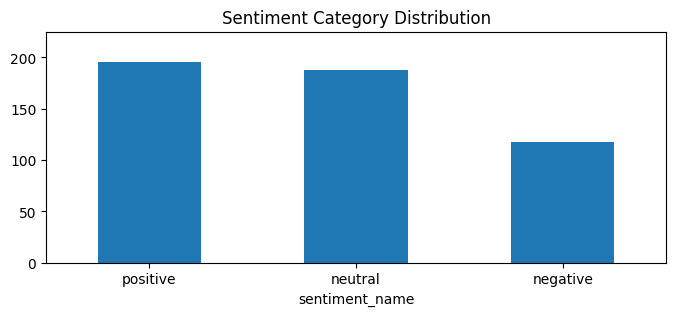

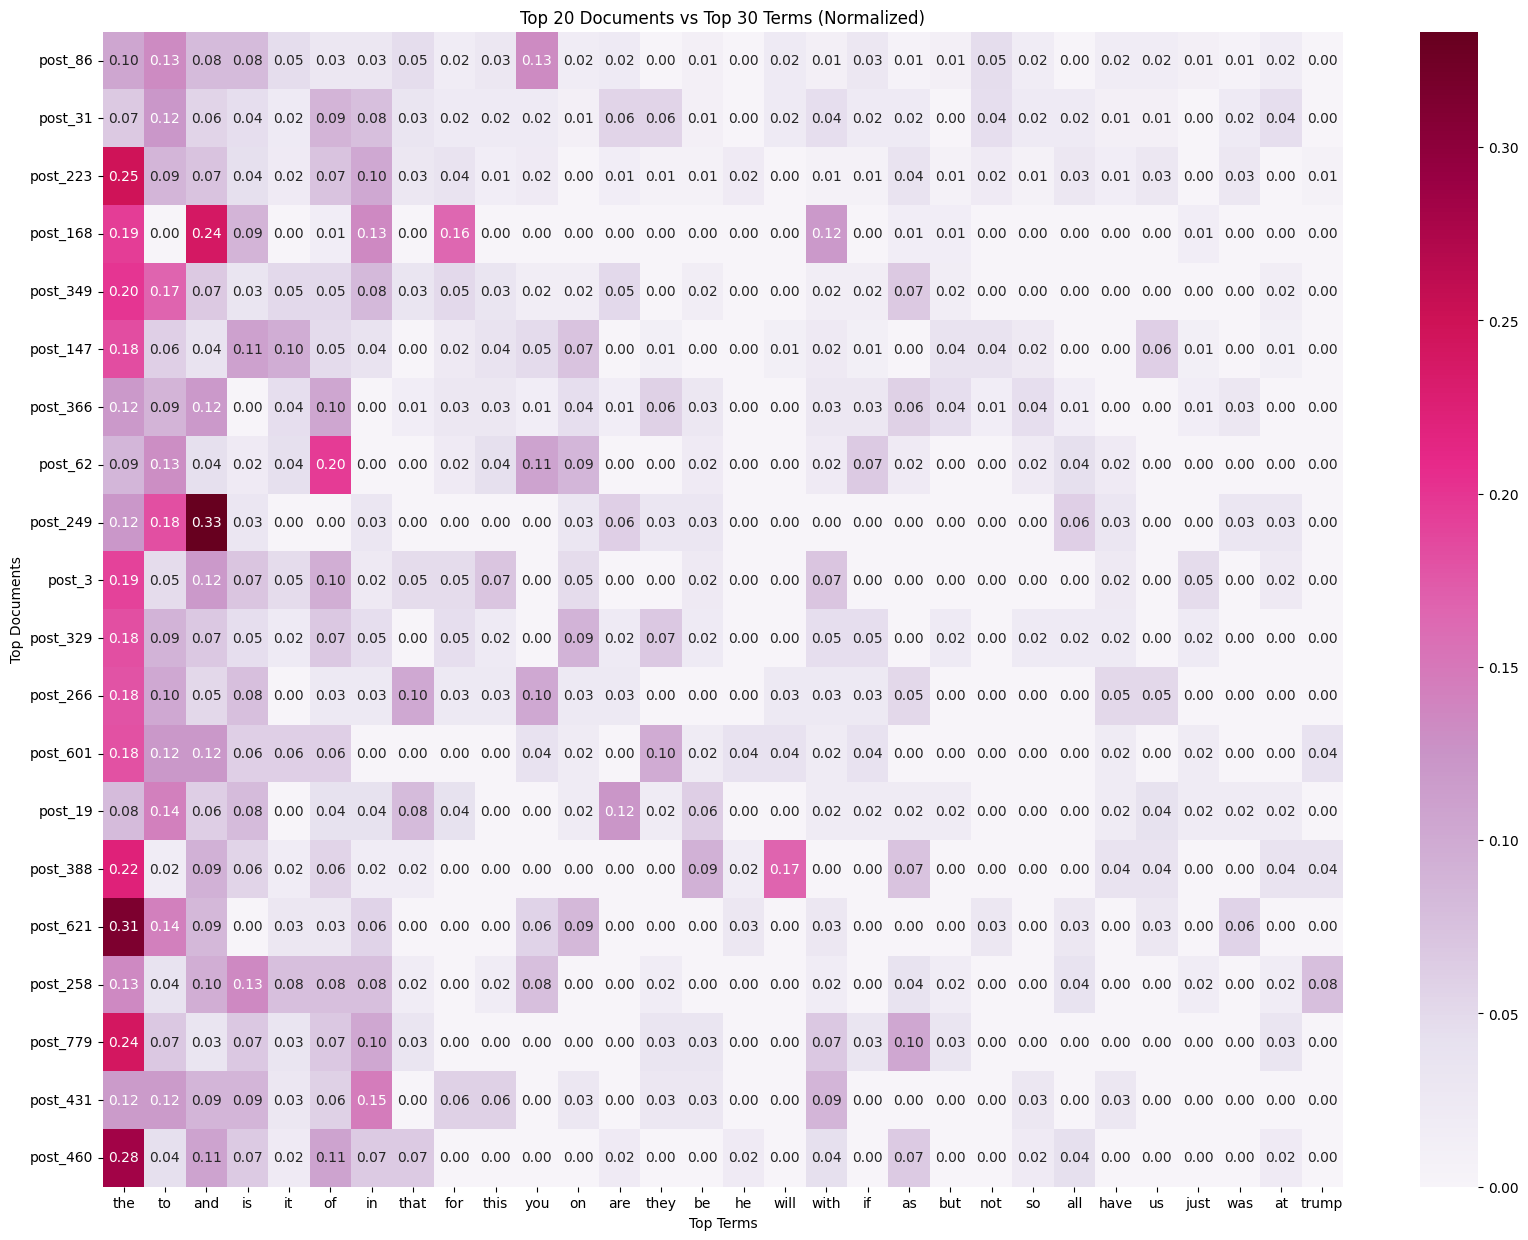

In [11]:
# --- Environment setup ---
import pandas as pd
import numpy as np
import nltk
nltk.download('punkt')
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
%matplotlib inline

# --- Helper functions ---
def simplify(df, columns):
    return df[columns].copy()

def add_mapping(df, mapping, target_column, source_column):
    df[target_column] = df[source_column].map(mapping)

# --- Load and prepare data ---
new_df = pd.read_csv('newdataset/Reddit-stock-sentiment.csv')
print(f"Shape: {new_df.shape}")
print(f"Columns: {new_df.columns}")

# Keep necessary columns
select_columns = ["text", "title", "sentiment", "subreddit", "label"]
X = simplify(new_df, select_columns)

# Map sentiment labels to readable names
mapping = {1.0: 'positive', 0.0: 'neutral', -1.0: 'negative'}
add_mapping(X, mapping, "sentiment_name", "sentiment")

# Drop duplicates
X.drop_duplicates(keep='first', inplace=True)
print(f"Dataset after dropping duplicates: {len(X)}")

# --- Quick EDA ---
print(X['sentiment_name'].value_counts())

# Optional: sample 500 posts for visualization
X_sample = X.sample(n=500, random_state=42)
X_sample.sentiment_name.value_counts().plot(
    kind='bar', title='Sentiment Category Distribution',
    ylim=[0, X_sample.sentiment_name.value_counts().max() + 30],
    rot=0, figsize=(8,3)
)
plt.show()

# --- Feature extraction ---
count_vect = CountVectorizer()
X_counts = count_vect.fit_transform(X.text)  # sparse matrix
terms = np.array(count_vect.get_feature_names_out())

# --- Top documents vs top terms heatmap ---
# Top 30 terms
term_frequencies = np.array(X_counts.sum(axis=0)).flatten()
top_terms_idx = np.argsort(term_frequencies)[-30:][::-1]

# Top 20 word-rich documents
post_word_counts = np.array(X_counts.sum(axis=1)).flatten()
top_posts_idx = np.argsort(post_word_counts)[-20:][::-1]

# Extract submatrix and normalize rows
submatrix = X_counts[top_posts_idx, :][:, top_terms_idx].toarray()
submatrix_norm = submatrix / submatrix.sum(axis=1, keepdims=True)

df_sub_norm = pd.DataFrame(
    submatrix_norm,
    index=[f"post_{i}" for i in top_posts_idx],
    columns=terms[top_terms_idx]
)

plt.figure(figsize=(20, 15))
sns.heatmap(df_sub_norm, cmap="PuRd", annot=True, fmt=".2f")
plt.title("Top 20 Documents vs Top 30 Terms (Normalized)")
plt.xlabel("Top Terms")
plt.ylabel("Top Documents")
plt.show()

# --- Sentiment-based word frequency analysis ---
# Convert boolean masks to integer indices
positive_indices = np.where(X['sentiment_name'] == 'positive')[0]
negative_indices = np.where(X['sentiment_name'] == 'negative')[0]

# Sum word counts
positive_word_freq = np.array(X_counts[positive_indices, :].sum(axis=0)).flatten()
negative_word_freq = np.array(X_counts[negative_indices, :].sum(axis=0)).flatten()

# Build DataFrames
df_positive = pd.DataFrame({"Term": terms, "Frequency": positive_word_freq})
df_negative = pd.DataFrame({"Term": terms, "Frequency": negative_word_freq})

# Log scale
df_positive["Frequency_log"] = np.log1p(df_positive["Frequency"])
df_negative["Frequency_log"] = np.log1p(df_negative["Frequency"])

# Top 100 words
df_positive_top = df_positive.sort_values(by="Frequency_log", ascending=False).head(100)
df_negative_top = df_negative.sort_values(by="Frequency_log", ascending=False).head(100)

# --- Plotly bar charts ---
fig_pos = px.bar(df_positive_top, x="Term", y="Frequency_log",
                 title="Top 100 Frequent Words (Positive Context, Log Scale)",
                 labels={"Frequency_log": "Log(Count + 1)"})
fig_pos.update_layout(xaxis_tickangle=-45, height=600, width=1200)
fig_pos.show()

fig_neg = px.bar(df_negative_top, x="Term", y="Frequency_log",
                 title="Top 100 Frequent Words (Negative Context, Log Scale)",
                 labels={"Frequency_log": "Log(Count + 1)"})
fig_neg.update_layout(xaxis_tickangle=-45, height=600, width=1200)
fig_neg.show()


In [12]:
X

,text,title,sentiment,subreddit,label,sentiment_name
0,Calls on retards,Retardation is on the menu boys! WSB is so back,-1.0,wallstreetbets,-1.0,negative
1,Stunt as in like why did they even make a big ...,Retail giant TARGET has now declined for 10 co...,1.0,wallstreetbets,0.0,positive
2,Seeing lots of red in the ticker.,How do you feel about a sitting president maki...,0.0,StockMarket,0.0,neutral
3,Vision Marine Technologies Inc. is rewriting t...,Who knows more? $VMAR,1.0,stockstobuytoday,1.0,positive
4,He didn’t say thank you.,The Trump administration is begging Xi Jinping...,0.0,StockMarket,-1.0,neutral
...,...,...,...,...,...,...
841,So countries “begging to stop the tariffs” and...,The Trump administration is begging Xi Jinping...,0.0,StockMarket,1.0,neutral
842,Invest now it is going to shoot up tomorrow,$MRIN Marin Software killed it today. Hope som...,0.0,stockstobuytoday,1.0,neutral
843,Where can I read this?,$ U.S. dollar value (crashing),0.0,StockMarket,0.0,neutral
845,i sold my puts so i expect cheeto to declare w...,Weekend Discussion Thread for the Weekend of A...,0.0,wallstreetbets,-1.0,neutral


# Phase 2

### 5.4.2 Finding Frequent pattern

In [13]:
### Begin Assignment Here
#Create separate DataFrames for each category
categories = X['sentiment_name'].unique()  # Get unique category labels
category_dfs = {}  # Dictionary to store DataFrames for each category

for category in categories:
    # Filter the original DataFrame by category
    category_dfs[category] = X[X['sentiment_name'] == category].copy()

# Function to create term-document frequency DataFrame for each category
def create_term_document_df(df):
    count_vect = CountVectorizer()  # Initialize the CountVectorizer
    X_counts = count_vect.fit_transform(df['text'])  # Transform the text data into word counts
    
    # Get the unique words (vocabulary) from the vectorizer
    words = count_vect.get_feature_names_out()
    
    # Create a DataFrame where rows are documents and columns are words
    term_document_df = pd.DataFrame(X_counts.toarray(), columns=words)
    
    return term_document_df

# Create term-document frequency DataFrames for each category
filt_term_document_dfs = {}  # Dictionary to store term-document DataFrames for each category

for category in categories:
    filt_term_document_dfs[category] = create_term_document_df(category_dfs[category])

In [14]:
category_number=2 #You can change it from 0 to 2
print(f"Filtered Term-Document Frequency DataFrame for Category {categories[category_number]}:")
filt_term_document_dfs[categories[category_number]]

Filtered Term-Document Frequency DataFrame for Category neutral:


,00,000,02,03,10,100,10yr,11,12,1242,...,year,years,yes,yesterday,yet,yields,yo,you,your,yup
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
2,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
308,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
309,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
310,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


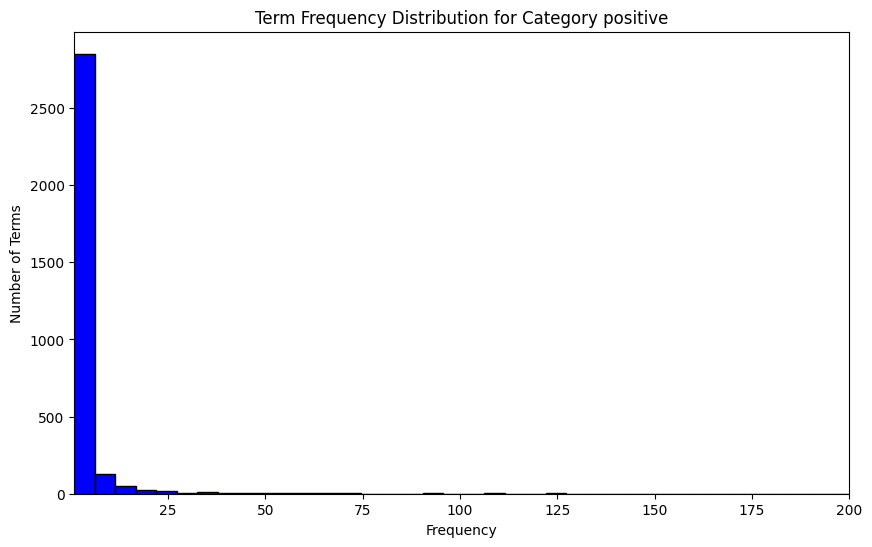

In [15]:
# Sum over all documents to get total frequency for each word
category_number=1 #You can change it from 0 to 2
word_counts = filt_term_document_dfs[categories[category_number]].sum(axis=0).to_numpy()
 
# Visualize the frequency distribution
plt.figure(figsize=(10, 6))
plt.hist(word_counts, bins=100, color='blue', edgecolor='black')
plt.title(f'Term Frequency Distribution for Category {categories[category_number]}')
plt.xlabel('Frequency')
plt.ylabel('Number of Terms')
plt.xlim(1, 200)
plt.show()

**Since it is based on the comments mostly, the top 5% and bottom 1% words may matters. We keep all the words for analyze. For example, top 5% from negative has the word "lithium". This reflects that the sentiment towards lithium is negative.**

In [ ]:
def filter_top_bottom_words_by_sum(term_document_df, top_percent=0.005, bottom_percent=0.005):
    # Calculate the sum of each word across all documents
    word_sums = term_document_df.sum(axis=0)
    
    # Sort the words by their total sum
    sorted_words = word_sums.sort_values()
    
    # Calculate the number of words to remove
    total_words = len(sorted_words)
    top_n = int(top_percent * total_words)
    bottom_n = int(bottom_percent * total_words)
    
    # Get the words to remove from the top 5% and bottom 1%
    words_to_remove = pd.concat([sorted_words.tail(top_n)]).index
    print(f'Bottom {bottom_percent*100}% words: \n{sorted_words.head(bottom_n)}') #Here we print which words correspond to the bottom percentage we filter
    print(f'Top {top_percent*100}% words: \n{sorted_words.tail(top_n)}') #Here we print which words correspond to the top percentage we filter
    # Return the DataFrame without the filtered words
    return term_document_df.drop(columns=words_to_remove)

# Apply the filtering function to each category
term_document_dfs = {}

for category in categories:
    print(f'\nFor category {category} we filter the following words:')
    term_document_dfs[category] = filter_top_bottom_words_by_sum(filt_term_document_dfs[category])


For category negative we filter the following words:
Bottom 0.5% words: 
ws      1
wsb     1
xeqt    1
1700    1
ya      1
2011    1
2s      1
11      1
dtype: int64
Top 0.5% words: 
that     65
of       67
in       70
it       99
is      113
and     121
to      144
the     235
dtype: int64

For category positive we filter the following words:
Bottom 0.5% words: 
208             1
wrote           1
1947            1
1945            1
186             1
17th            1
1728            1
160             1
15m             1
150             1
yoyo            1
reservations    1
researches      1
research        1
requires        1
dtype: int64
Top 0.5% words: 
with     86
are      92
they     92
you     108
on      111
that    127
for     127
this    128
in      175
it      187
of      194
is      213
and     305
to      328
the     527
dtype: int64

For category neutral we filter the following words:
Bottom 0.5% words: 
18630    1
1870     1
1934     1
1945     1
1m       1
20       1
d

**Convert dataframe to transactional database**

In [195]:
from PAMI.extras.convert.DF2DB import DF2DB            

# Loop through the dictionary of term-document DataFrames
for category in term_document_dfs:
    # Replace dots with underscores in the category name to avoid errors in the file creation
    category_safe = category.replace('.', '_')
    
    # Create the DenseFormatDF object and convert to a transactional database
    obj = DF2DB(term_document_dfs[category])           
        
    obj.convert2TransactionalDatabase(f'td_freq_db_{category_safe}.csv', '>=', 1)


**Check the conversion**

Database size (total no of transactions) : 196
Number of items : 1623
Minimum Transaction Size : 1
Average Transaction Size : 19.301020408163264
Maximum Transaction Size : 94
Standard Deviation Transaction Size : 15.676128966263656
Variance in Transaction Sizes : 247.00122972265828
Sparsity : 0.9881078124410577


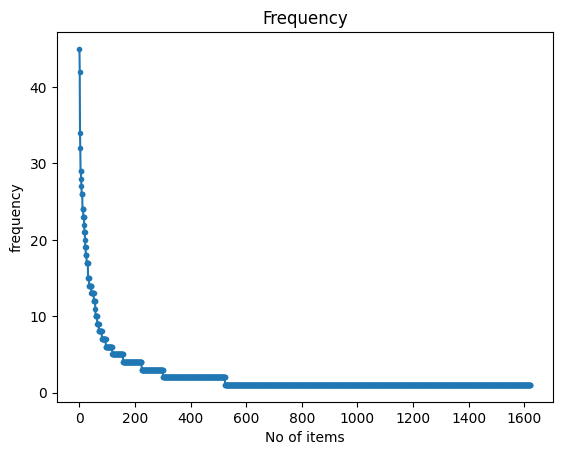

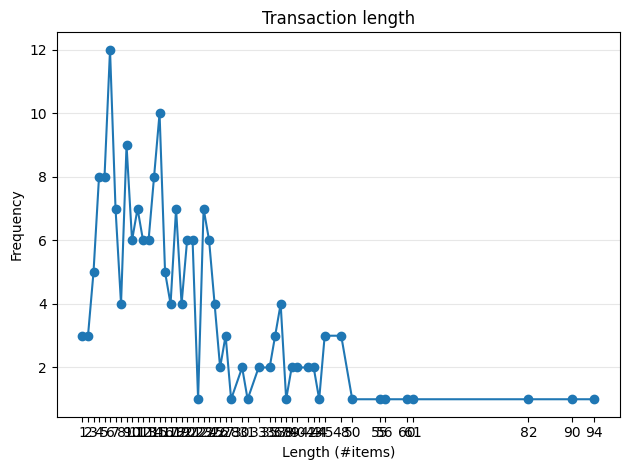

In [196]:
from PAMI.extras.dbStats import TransactionalDatabase as tds
obj = tds.TransactionalDatabase('td_freq_db_negative.csv')
obj.run()
obj.printStats()
obj.plotGraphs()

Database size (total no of transactions) : 310
Number of items : 1261
Minimum Transaction Size : 1
Average Transaction Size : 8.393548387096773
Maximum Transaction Size : 32
Standard Deviation Transaction Size : 6.359140512216277
Variance in Transaction Sizes : 40.56953753001358
Sparsity : 0.9933437364099154


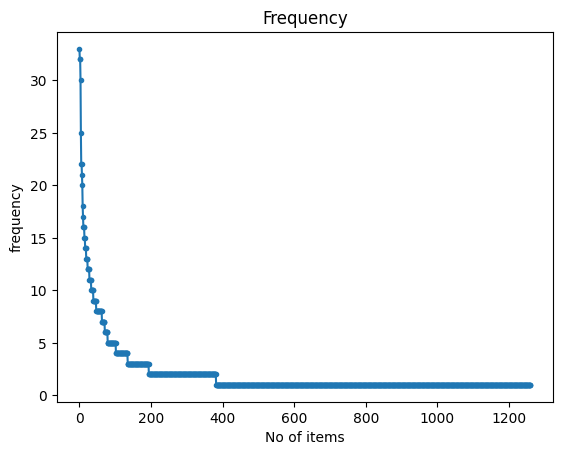

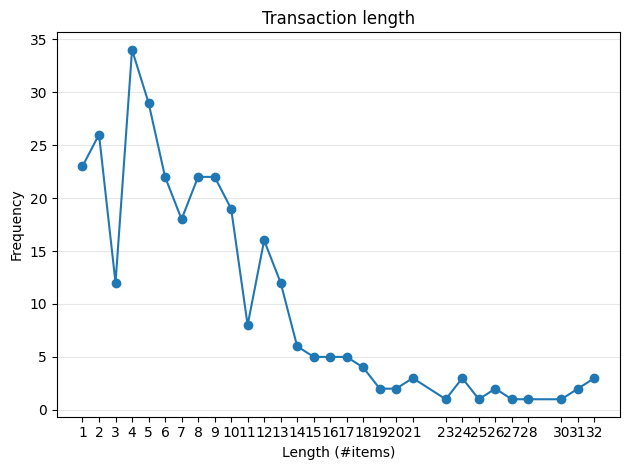

In [197]:
obj = tds.TransactionalDatabase('td_freq_db_neutral.csv')
obj.run()
obj.printStats()
obj.plotGraphs()

Database size (total no of transactions) : 316
Number of items : 3112
Minimum Transaction Size : 1
Average Transaction Size : 25.67721518987342
Maximum Transaction Size : 249
Standard Deviation Transaction Size : 30.81627241262949
Variance in Transaction Sizes : 952.6573839662448
Sparsity : 0.9917489668413003


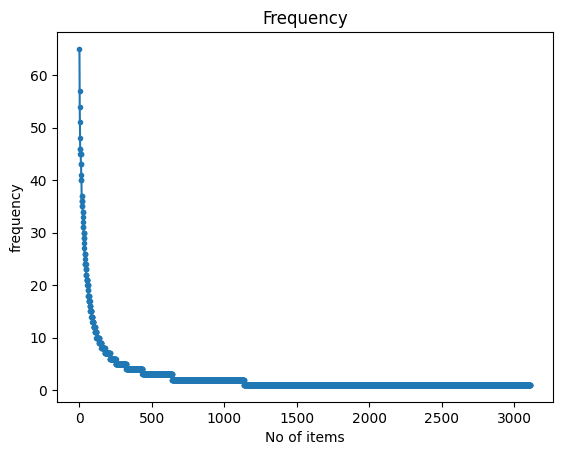

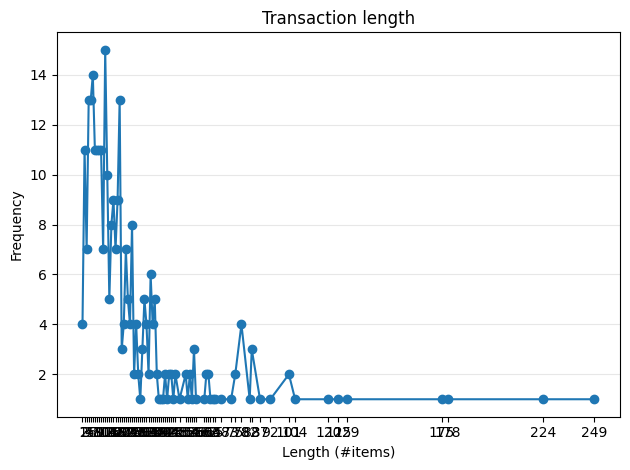

In [198]:
obj = tds.TransactionalDatabase('td_freq_db_positive.csv')
obj.run()
obj.printStats()
obj.plotGraphs()

**Mine patterns using FPGrowth Algorithm**

In [199]:
def filter_top_patterns_by_support(patterns_df, top_percent=0.025, bottom_percent=0.025):
    """
    Remove the top and bottom X% of patterns based on their Support value.

    Parameters:
        patterns_df (pd.DataFrame): DataFrame containing a 'Support' column.
        top_percent (float): Fraction of top patterns to remove (default 0.025 = 2.5%).
        bottom_percent (float): Fraction of bottom patterns to remove (default 0.025 = 2.5%).

    Returns:
        pd.DataFrame: DataFrame with top and bottom patterns removed.
    """

    # Sort by support
    sorted_df = patterns_df.sort_values(by='Support', ascending=True)

    # Compute how many patterns to remove
    total_patterns = len(sorted_df)
    top_n = int(top_percent * total_patterns)
    bottom_n = int(bottom_percent * total_patterns)

    # Identify patterns to remove
    patterns_to_remove = pd.concat([
        sorted_df.head(bottom_n),  # bottom 2.5%
        sorted_df.tail(top_n)      # top 2.5%
    ]).index

    # Print which patterns were removed
    print(f'Bottom {bottom_percent*100}% patterns:\n{sorted_df.head(bottom_n)}\n')
    print(f'Top {top_percent*100}% patterns:\n{sorted_df.tail(top_n)}\n')

    # Remove them from the original DataFrame
    filtered_df = patterns_df.drop(index=patterns_to_remove)

    return filtered_df


In [200]:
from PAMI.frequentPattern.basic import FPGrowth as alg
minSup=10
obj1 = alg.FPGrowth(iFile='td_freq_db_negative.csv', minSup=minSup)
obj1.mine()
frequentPatternsDF_negative= obj1.getPatternsAsDataFrame()
#frequentPatternsDF_negative = filter_top_patterns_by_support(frequentPatternsDF_negative)
print('Total No of patterns: ' + str(len(frequentPatternsDF_negative))) #print the total number of patterns
print('Runtime: ' + str(obj1.getRuntime())) #measure the runtime
# print(frequentPatternsDF_negative.columns)
# print(frequentPatternsDF_negative.head())

Frequent patterns were generated successfully using frequentPatternGrowth algorithm
Total No of patterns: 81
Runtime: 0.005750894546508789


In [201]:
frequentPatternsDF_negative

,Patterns,Support
0,me,10
1,why,10
2,out,10
3,go,10
4,one,10
...,...,...
76,you,34
77,you\tthis,13
78,for,42
79,for\tthis,14


In [202]:
obj2 = alg.FPGrowth(iFile='td_freq_db_neutral.csv', minSup=minSup)
obj2.mine()
frequentPatternsDF_neutral= obj2.getPatternsAsDataFrame()
#frequentPatternsDF_neutral = filter_top_patterns_by_support(frequentPatternsDF_neutral)
print('Total No of patterns: ' + str(len(frequentPatternsDF_neutral))) #print the total number of patterns
print('Runtime: ' + str(obj2.getRuntime())) #measure the runtime

Frequent patterns were generated successfully using frequentPatternGrowth algorithm
Total No of patterns: 40
Runtime: 0.007141590118408203


In [203]:
frequentPatternsDF_neutral

,Patterns,Support
0,going,10
1,com,10
2,stockbuyvest,10
3,stockbuyvest\tcom,10
4,do,10
5,has,10
6,get,10
7,them,11
8,we,11
9,was,11


In [204]:
obj3 = alg.FPGrowth(iFile='td_freq_db_positive.csv', minSup=minSup)
obj3.mine()
frequentPatternsDF_positive= obj3.getPatternsAsDataFrame()
#frequentPatternsDF_positive = filter_top_patterns_by_support(frequentPatternsDF_positive)
print('Total No of patterns: ' + str(len(frequentPatternsDF_positive))) #print the total number of patterns
print('Runtime: ' + str(obj3.getRuntime())) #measure the runtime

Frequent patterns were generated successfully using frequentPatternGrowth algorithm
Total No of patterns: 419
Runtime: 0.02475452423095703


In [205]:
frequentPatternsDF_positive

,Patterns,Support
0,ll,10
1,looking,10
2,pretty,10
3,long,10
4,term,10
...,...,...
414,if\tbut\tbe,12
415,if\tbe,26
416,but,57
417,but\tbe,18


In [ ]:
# from PAMI.frequentPattern.topk import FAE as algo1
# from PAMI.frequentPattern.maximal import MaxFPGrowth as algo2
# # obj = algo1.FAE(iFile='td_freq_db_negative.csv', k= 500, sep='\t')
# # obj.mine()
# # obj1 = algo1.FAE(iFile='td_freq_db_neutral.csv', k= 500, sep='\t')
# # obj1.mine()
# # obj2 = algo1.FAE(iFile='td_freq_db_positve.csv', k= 500, sep='\t')
# # obj2.mine()
# obj = algo2.MaxFPGrowth(iFile='td_freq_db_negative.csv', minSup=9,sep='\t')
# obj.mine()
# obj1 = algo2.MaxFPGrowth(iFile='td_freq_db_neutral.csv', minSup=9,sep='\t')
# obj1.mine()
# obj2 = algo2.MaxFPGrowth(iFile='td_freq_db_positive.csv', minSup=9,sep='\t')
# obj2.mine()
# frequentPatternsDF_negative= obj.getPatternsAsDataFrame()
# frequentPatternsDF_neutral= obj1.getPatternsAsDataFrame()
# frequentPatternsDF_positive= obj2.getPatternsAsDataFrame()

Maximal Frequent patterns were generated successfully using MaxFp-Growth algorithm 
Maximal Frequent patterns were generated successfully using MaxFp-Growth algorithm 
Maximal Frequent patterns were generated successfully using MaxFp-Growth algorithm 


**Identify unique patterns**

In [237]:
import pandas as pd

#We group together all of the dataframes related to our found patterns
dfs = [frequentPatternsDF_negative, frequentPatternsDF_positive, frequentPatternsDF_neutral]


# Identify patterns that appear in more than one category
# Count how many times each pattern appears across all dataframes
pattern_counts = {}
for df in dfs:
    for pattern in df['Patterns']:
        if pattern not in pattern_counts:
            pattern_counts[pattern] = 1
        else:
            pattern_counts[pattern] += 1

# Filter out patterns that appear in more than one dataframe
unique_patterns = {pattern for pattern, count in pattern_counts.items() if count == 1}
# Calculate the total number of patterns across all categories
total_patterns_count = sum(len(df) for df in dfs)
# Calculate how many patterns were discarded
discarded_patterns_count = total_patterns_count - len(unique_patterns)

# For each category, filter the patterns to keep only the unique ones
filtered_dfs = []
for df in dfs:
    filtered_df = df[df['Patterns'].isin(unique_patterns)]
    filtered_dfs.append(filtered_df)

# Merge the filtered dataframes into a final dataframe
final_pattern_df = pd.concat(filtered_dfs, ignore_index=True)

# Sort by support
final_pattern_df = final_pattern_df.sort_values(by='Support', ascending=False)

# Display the final result
print(final_pattern_df)
# Print the number of discarded patterns
print(f"Number of patterns discarded: {discarded_patterns_count}")

       Patterns  Support
503       that        33
502        you        32
501        for        32
500         in        30
499       this        25
..          ...      ...
17      for an         9
14   this when         9
2         shit         9
1         time         9
0         want         9

[504 rows x 2 columns]
Number of patterns discarded: 70


**Integrate category specific patterns to our data**

In [238]:
from sklearn.feature_extraction.text import CountVectorizer

# Convert 'text' column into term-document matrix using CountVectorizer
count_vect = CountVectorizer()
X_tdm = count_vect.fit_transform(X['text'])  # X['text'] contains your text data
terms = count_vect.get_feature_names_out()  # Original terms in the vocabulary

# Tokenize the sentences into sets of unique words
X['tokenized_text'] = X['text'].str.split().apply(set)

# Initialize the pattern matrix
pattern_matrix = pd.DataFrame(0, index=X.index, columns=final_pattern_df['Patterns'])

# Iterate over each pattern and check if all words in the pattern are present in the tokenized sentence
for pattern in final_pattern_df['Patterns']:
    pattern_words = set(pattern.split())  # Tokenize pattern into words
    pattern_matrix[pattern] = X['tokenized_text'].apply(lambda x: 1 if pattern_words.issubset(x) else 0)

# Convert the term-document matrix to a DataFrame for easy merging
tdm_df = pd.DataFrame(X_tdm.toarray(), columns=terms, index=X.index)

# Concatenate the original TDM and the pattern matrix to augment the features
augmented_df = pd.concat([tdm_df, pattern_matrix], axis=1)

augmented_df

,00,000,01378,02,027,03,06,08,10,100,...,be as have,be if all,today,any,like,for an,this when,shit,time,want
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,1,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
841,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
842,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
843,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
845,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


**Using FAE and MaxFPGrowth to analyze**

In [239]:
from PAMI.frequentPattern.topk import FAE as algo1
from PAMI.frequentPattern.maximal import MaxFPGrowth as algo2
FILE = "td_freq_db_negative.csv"
obj = algo1.FAE(iFile=FILE, k= 50, sep='\t')
obj.mine()
frequentPatternsDF= obj.getPatternsAsDataFrame()

 TopK frequent patterns were successfully generated using FAE algorithm.


**FAE**

In [240]:
obj = algo1.FAE(iFile=FILE, k= 50, sep='\t')
obj.mine()
frequentPatternsDF= obj.getPatternsAsDataFrame()
print('Total No of patterns: ' + str(len(frequentPatternsDF)))
print('Runtime: ' + str(obj.getRuntime()))
frequentPatternsDF

 TopK frequent patterns were successfully generated using FAE algorithm.
Total No of patterns: 50
Runtime: 0.012778997421264648


,Patterns,Support
0,this,45
1,for,42
2,you,34
3,he,32
4,on,29
5,so,29
6,trump,28
7,if,27
8,be,26
9,can,26


In [241]:
obj = algo1.FAE(iFile=FILE, k=100, sep='\t')
obj.mine()
frequentPatternsDF= obj.getPatternsAsDataFrame()
print('Total No of patterns: ' + str(len(frequentPatternsDF)))
print('Runtime: ' + str(obj.getRuntime()))
frequentPatternsDF

 TopK frequent patterns were successfully generated using FAE algorithm.
Total No of patterns: 100
Runtime: 0.017000675201416016


,Patterns,Support
0,this,45
1,for,42
2,you,34
3,he,32
4,on,29
...,...,...
95,for an,9
96,you can,9
97,he not,9
98,if be,9


In [242]:
obj = algo1.FAE(iFile=FILE, k=200, sep='\t')
obj.mine()
frequentPatternsDF= obj.getPatternsAsDataFrame()
print('Total No of patterns: ' + str(len(frequentPatternsDF)))
print('Runtime: ' + str(obj.getRuntime()))
frequentPatternsDF

 TopK frequent patterns were successfully generated using FAE algorithm.
Total No of patterns: 200
Runtime: 0.05358529090881348


,Patterns,Support
0,this,45
1,for,42
2,you,34
3,he,32
4,on,29
...,...,...
195,but tariffs,7
196,are what,7
197,are all,7
198,will have,7


**MaxFPGrowth**

In [243]:
obj = algo2.MaxFPGrowth(iFile=FILE, minSup=3,sep='\t')
obj.mine()
frequentPatternsDF= obj.getPatternsAsDataFrame()
print('Total No of patterns: ' + str(len(frequentPatternsDF)))
print('Runtime: ' + str(obj.getRuntime()))
frequentPatternsDF

Maximal Frequent patterns were generated successfully using MaxFp-Growth algorithm 
Total No of patterns: 1152
Runtime: 0.06259489059448242


,Patterns,Support
0,beyond,3
1,start,3
2,support,3
3,person,3
4,try,3
...,...,...
1147,he on trump,3
1148,this he so,3
1149,this you so,4
1150,for on so,3


In [244]:
obj = algo2.MaxFPGrowth(iFile=FILE, minSup=6,sep='\t')
obj.mine()
frequentPatternsDF= obj.getPatternsAsDataFrame()
print('Total No of patterns: ' + str(len(frequentPatternsDF)))
print('Runtime: ' + str(obj.getRuntime()))
frequentPatternsDF

Maximal Frequent patterns were generated successfully using MaxFp-Growth algorithm 
Total No of patterns: 238
Runtime: 0.014999151229858398


,Patterns,Support
0,year,6
1,into,6
2,probably,6
3,other,6
4,ll,6
...,...,...
233,for so,9
234,this so,12
235,for on,7
236,this on,7


In [245]:
obj = algo2.MaxFPGrowth(iFile=FILE, minSup=9,sep='\t')
obj.mine()
frequentPatternsDF= obj.getPatternsAsDataFrame()
print('Total No of patterns: ' + str(len(frequentPatternsDF)))
print('Runtime: ' + str(obj.getRuntime()))
frequentPatternsDF

Maximal Frequent patterns were generated successfully using MaxFp-Growth algorithm 
Total No of patterns: 82
Runtime: 0.01417088508605957


,Patterns,Support
0,our,9
1,want,9
2,time,9
3,still,9
4,too,9
...,...,...
77,on,29
78,for he,9
79,this he,12
80,this you,13


### 5.5 Dimensionality Reduction

In [246]:
#Applying dimensionality reduction with only the document-term frequency data
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap.umap_ as umap
import matplotlib.pyplot as plt

#This might take a couple of minutes to execute
# Apply PCA, t-SNE, and UMAP to the data
X_pca_tdm = PCA(n_components=2).fit_transform(tdm_df.values)
X_tsne_tdm = TSNE(n_components=2).fit_transform(tdm_df.values)
X_umap_tdm = umap.UMAP(n_components=2).fit_transform(tdm_df.values)

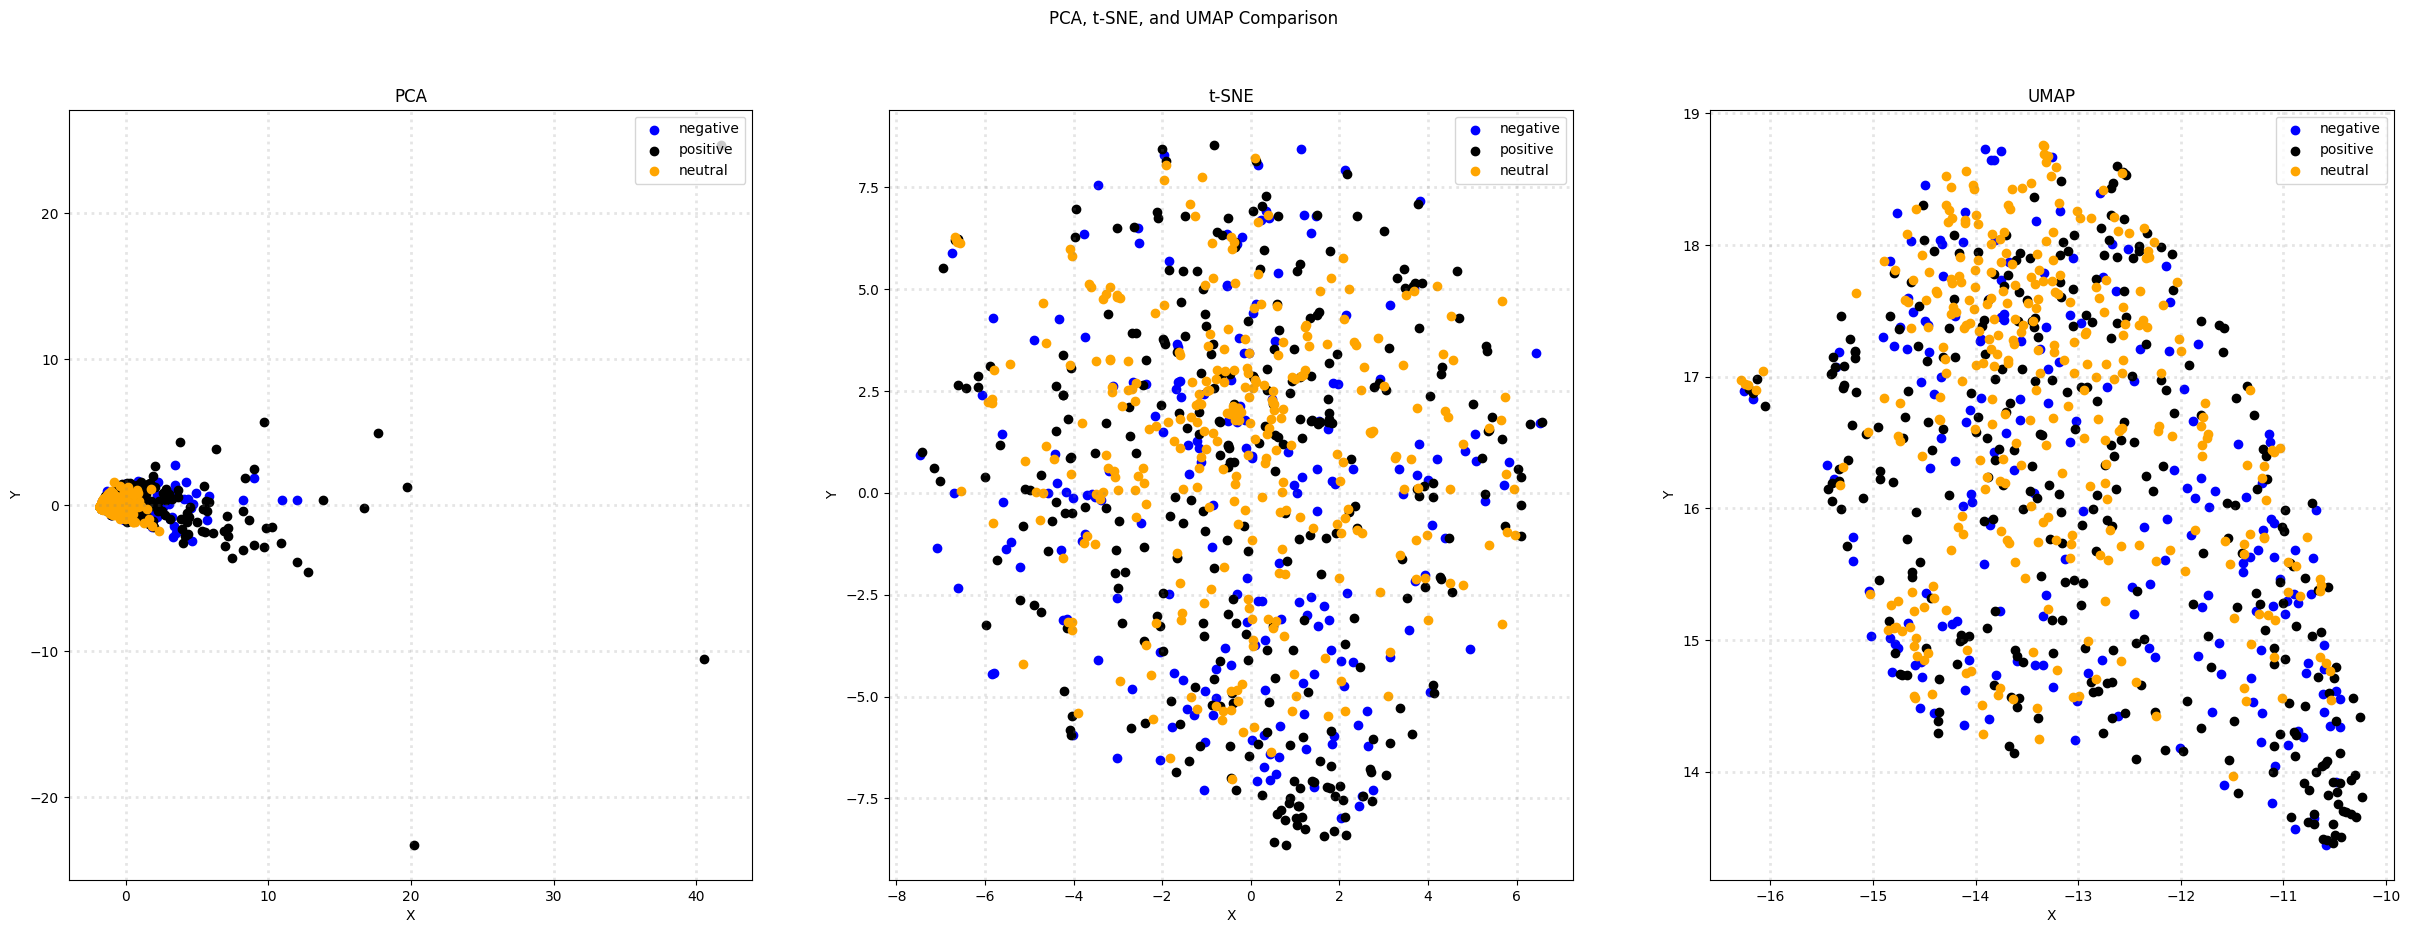

In [247]:
# Plot the results in subplots
col = ['blue', 'black', 'orange']
categories = X['sentiment_name'].unique() 

fig, axes = plt.subplots(1, 3, figsize=(30, 10))  # Create 3 subplots for PCA, t-SNE, and UMAP
fig.suptitle('PCA, t-SNE, and UMAP Comparison')

# Define a function to create a scatter plot for each method
def plot_scatter(ax, X_reduced, title):
    for c, category in zip(col, categories):
        xs = X_reduced[X['sentiment_name'] == category].T[0]
        ys = X_reduced[X['sentiment_name'] == category].T[1]
        ax.scatter(xs, ys, c=c, marker='o', label=category)
    
    ax.grid(color='gray', linestyle=':', linewidth=2, alpha=0.2)
    ax.set_title(title)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.legend(loc='upper right')

# Step 4: Create scatter plots for PCA, t-SNE, and UMAP
plot_scatter(axes[0], X_pca_tdm, 'PCA')
plot_scatter(axes[1], X_tsne_tdm, 't-SNE')
plot_scatter(axes[2], X_umap_tdm, 'UMAP')

plt.show()

**Using augmented data**

In [248]:
#This might take a couple of minutes to execute
#Applying dimensionality reduction with both the document-term frequency data and the pattern derived data
# Apply PCA, t-SNE, and UMAP to the data
X_pca_aug = PCA(n_components=2).fit_transform(augmented_df.values)
X_tsne_aug = TSNE(n_components=2).fit_transform(augmented_df.values)
X_umap_aug = umap.UMAP(n_components=2).fit_transform(augmented_df.values)

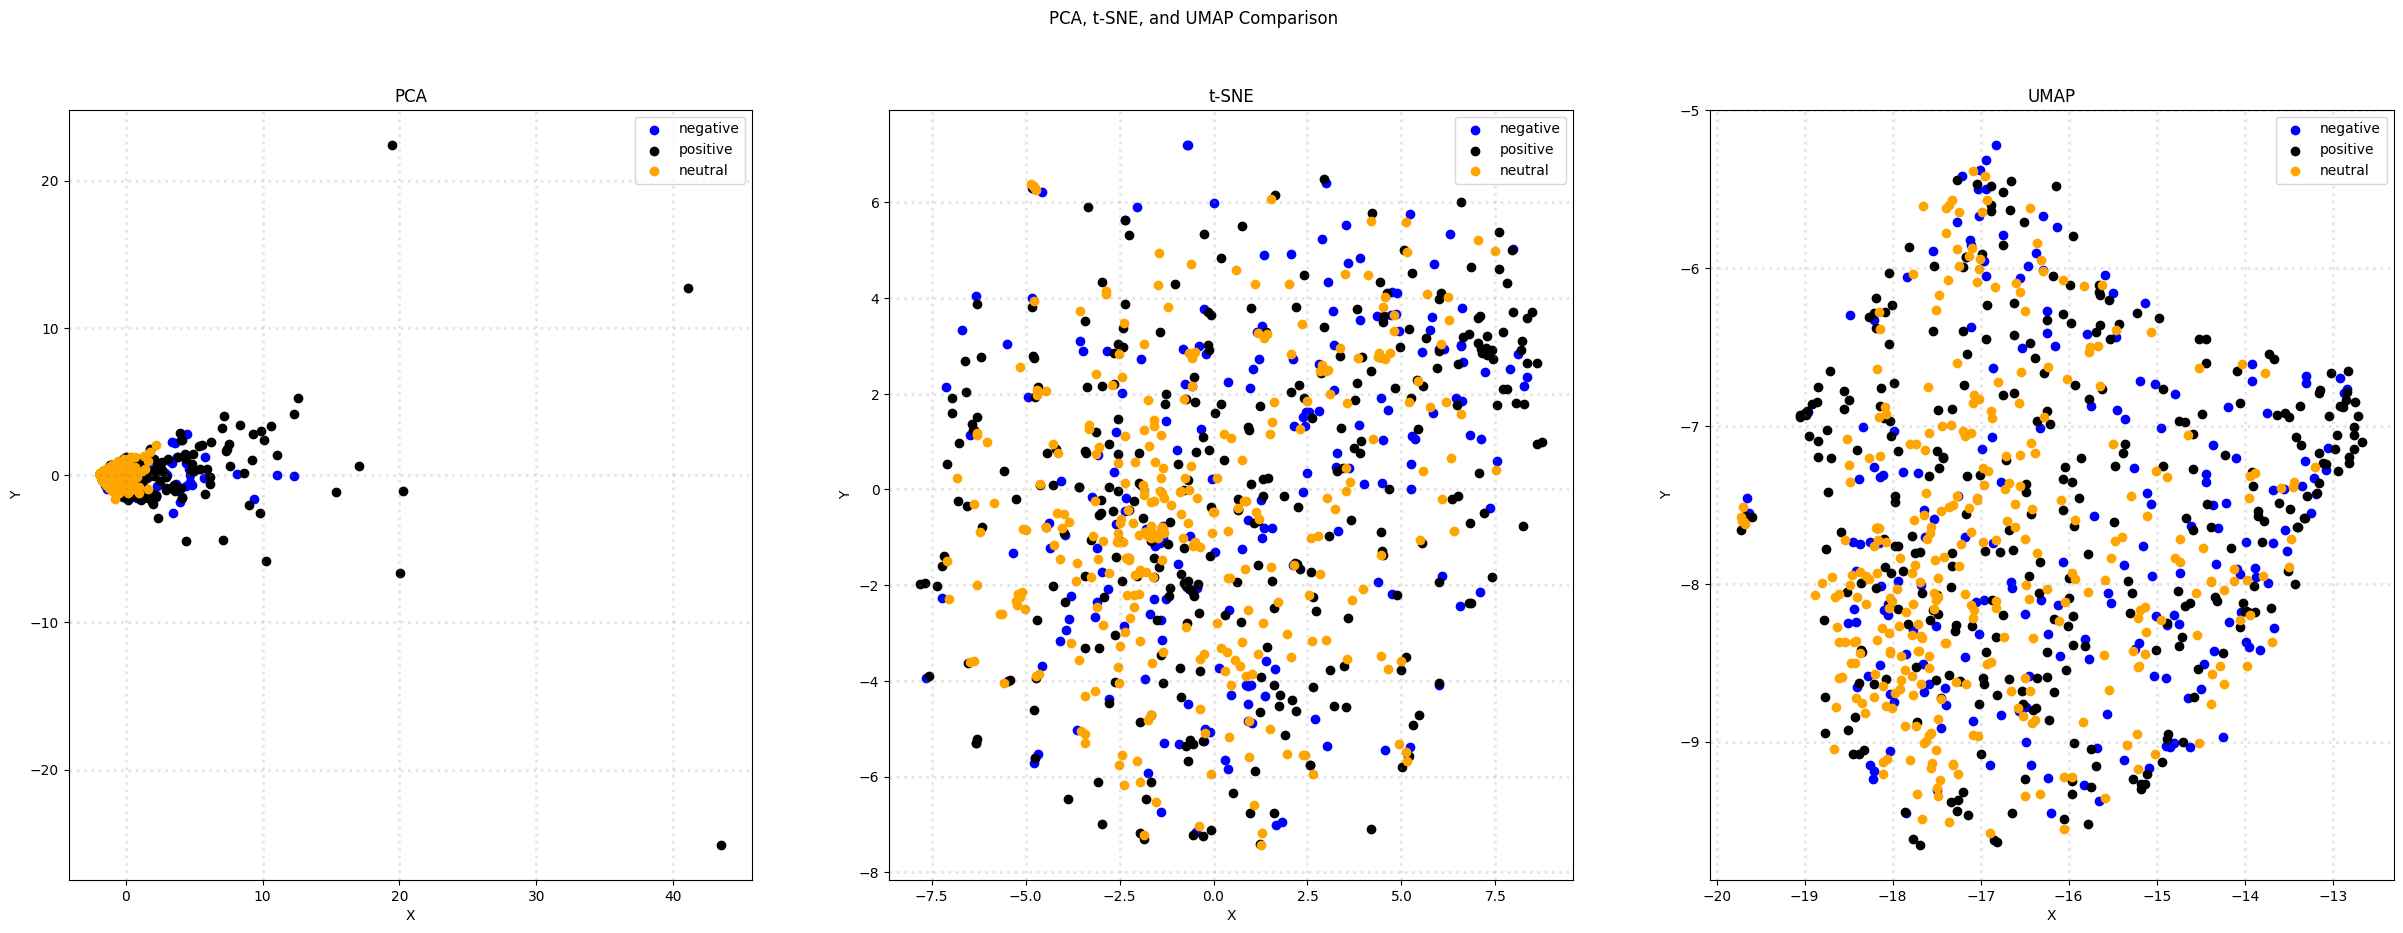

In [249]:
# Plot the results in subplots
col = ['blue', 'black', 'orange']
categories = X['sentiment_name'].unique() 

fig, axes = plt.subplots(1, 3, figsize=(30, 10))  # Create 3 subplots for PCA, t-SNE, and UMAP
fig.suptitle('PCA, t-SNE, and UMAP Comparison')

# Define a function to create a scatter plot for each method
def plot_scatter(ax, X_reduced, title):
    for c, category in zip(col, categories):
        xs = X_reduced[X['sentiment_name'] == category].T[0]
        ys = X_reduced[X['sentiment_name'] == category].T[1]
        ax.scatter(xs, ys, c=c, marker='o', label=category)
    
    ax.grid(color='gray', linestyle=':', linewidth=2, alpha=0.2)
    ax.set_title(title)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.legend(loc='upper right')

# Create scatter plots for PCA, t-SNE, and UMAP
plot_scatter(axes[0], X_pca_aug, 'PCA')
plot_scatter(axes[1], X_tsne_aug, 't-SNE')
plot_scatter(axes[2], X_umap_aug, 'UMAP')

plt.show()

**3D plots for augmented data**

c:\Users\user\OneDrive - NTHU\桌面\Data Mining\DM2025Labs\DM2025-Lab1-Exercise\.venv\lib\site-packages\umap\umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



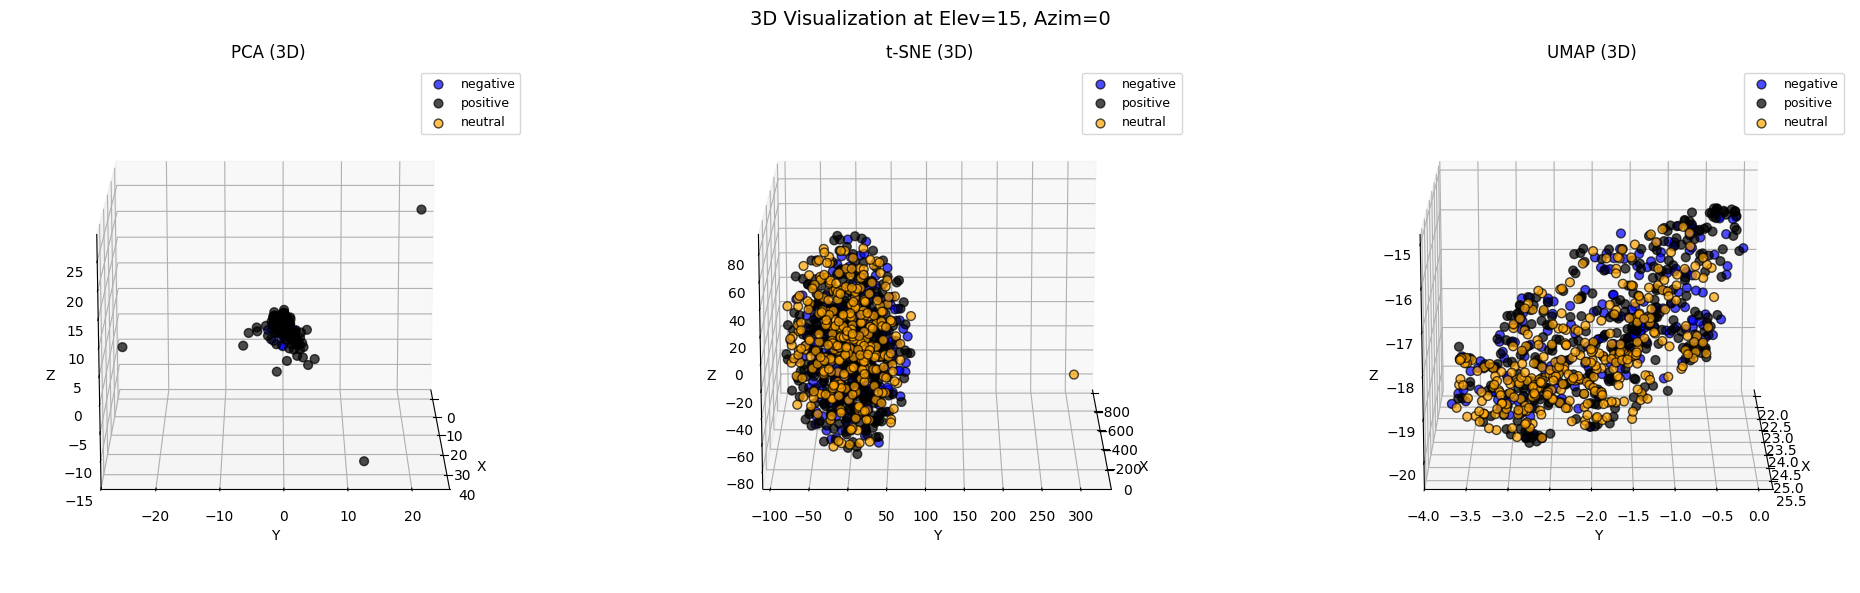

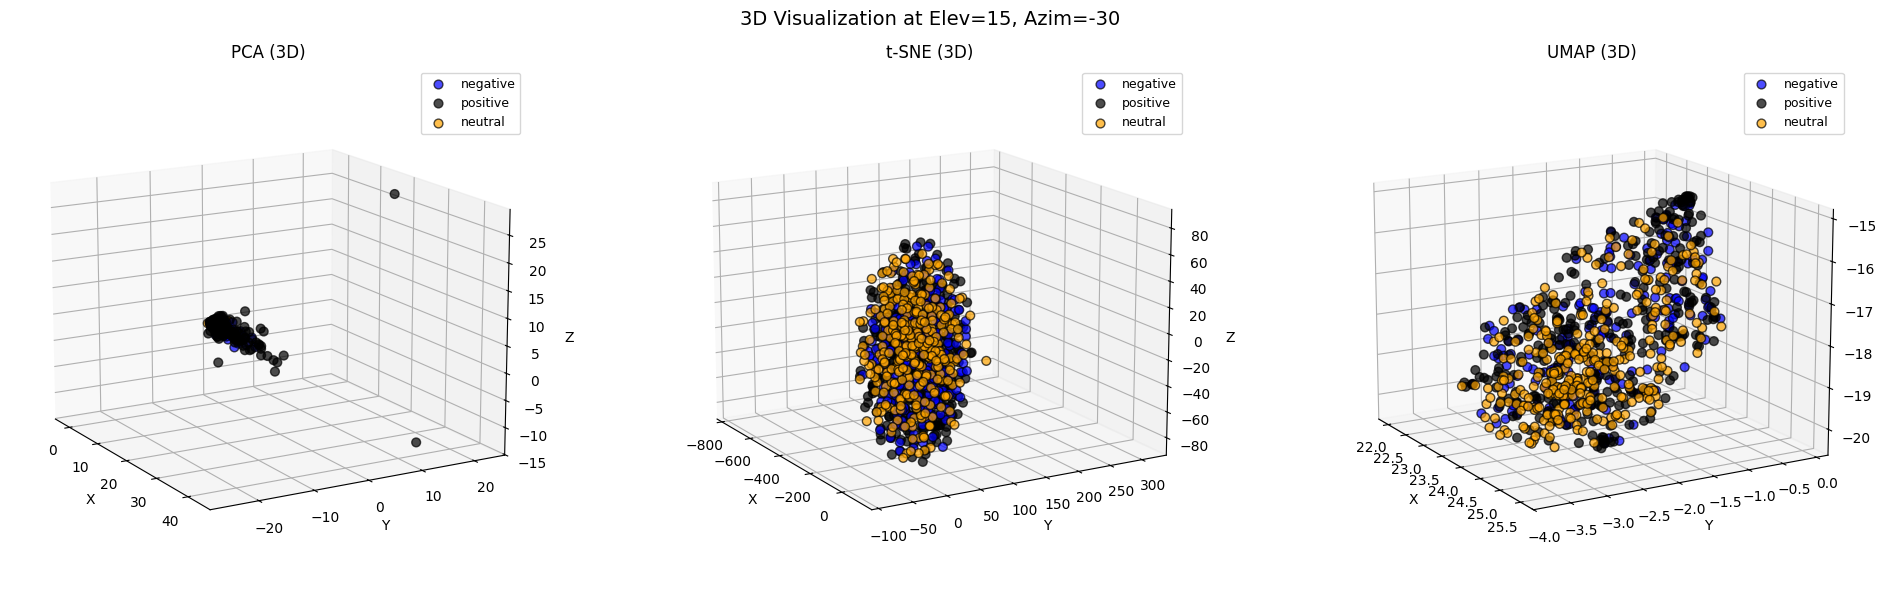

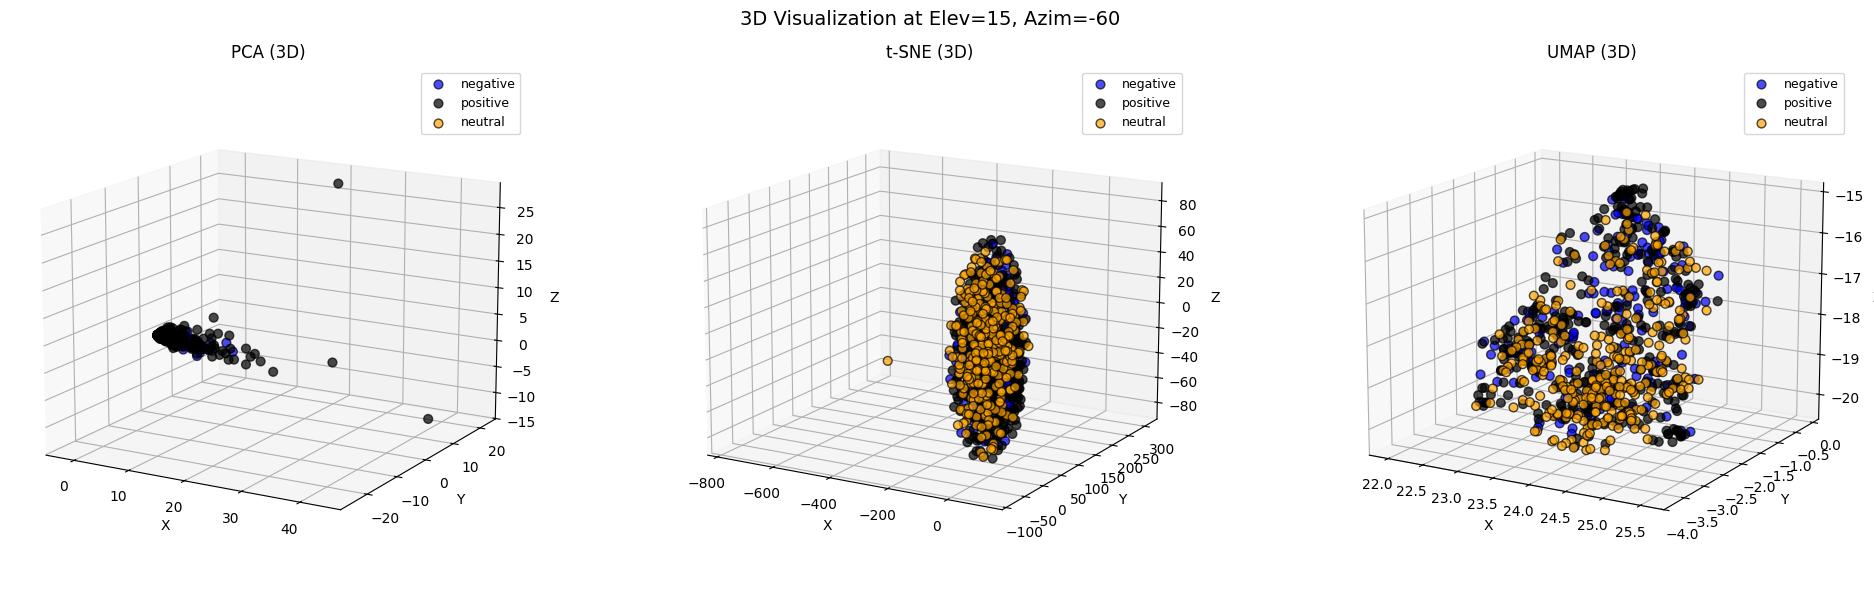

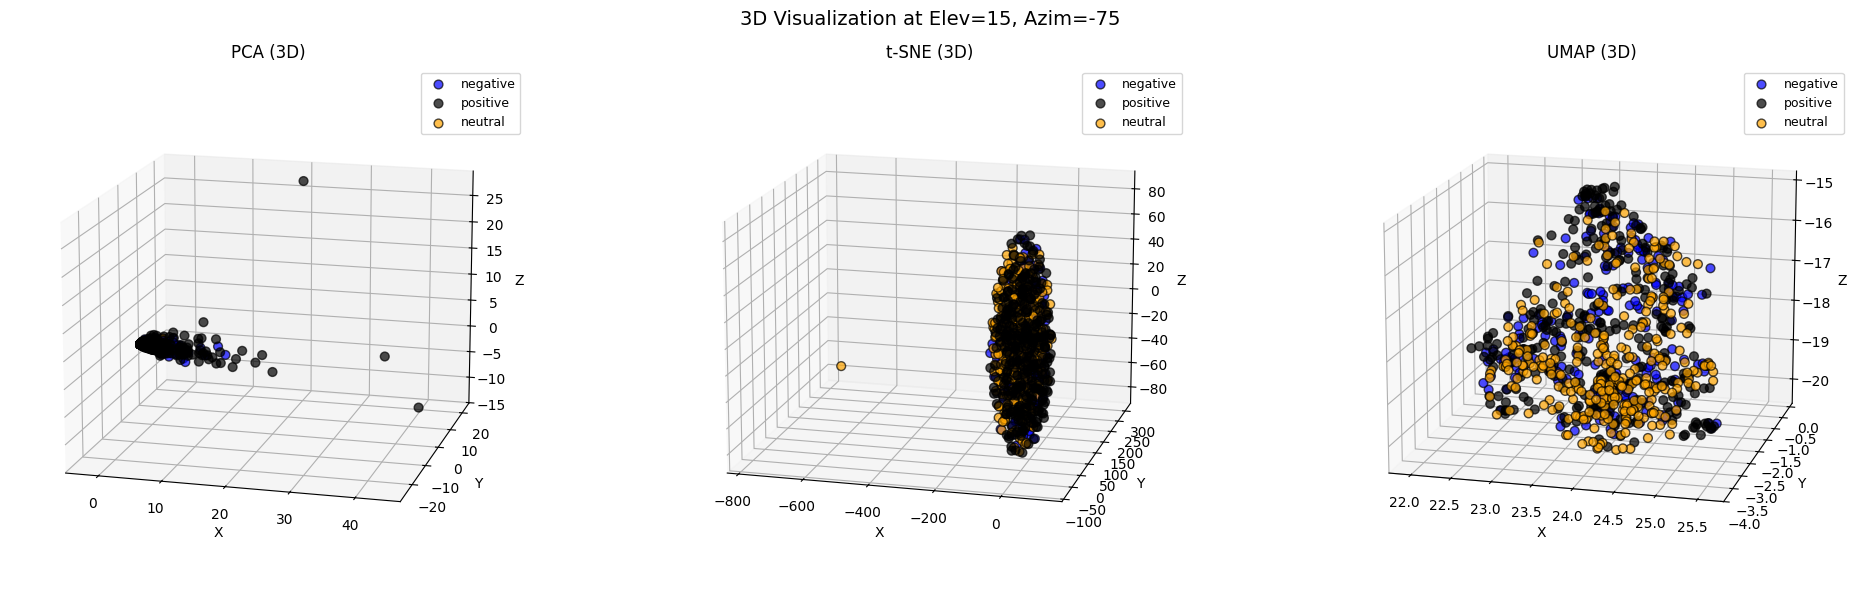

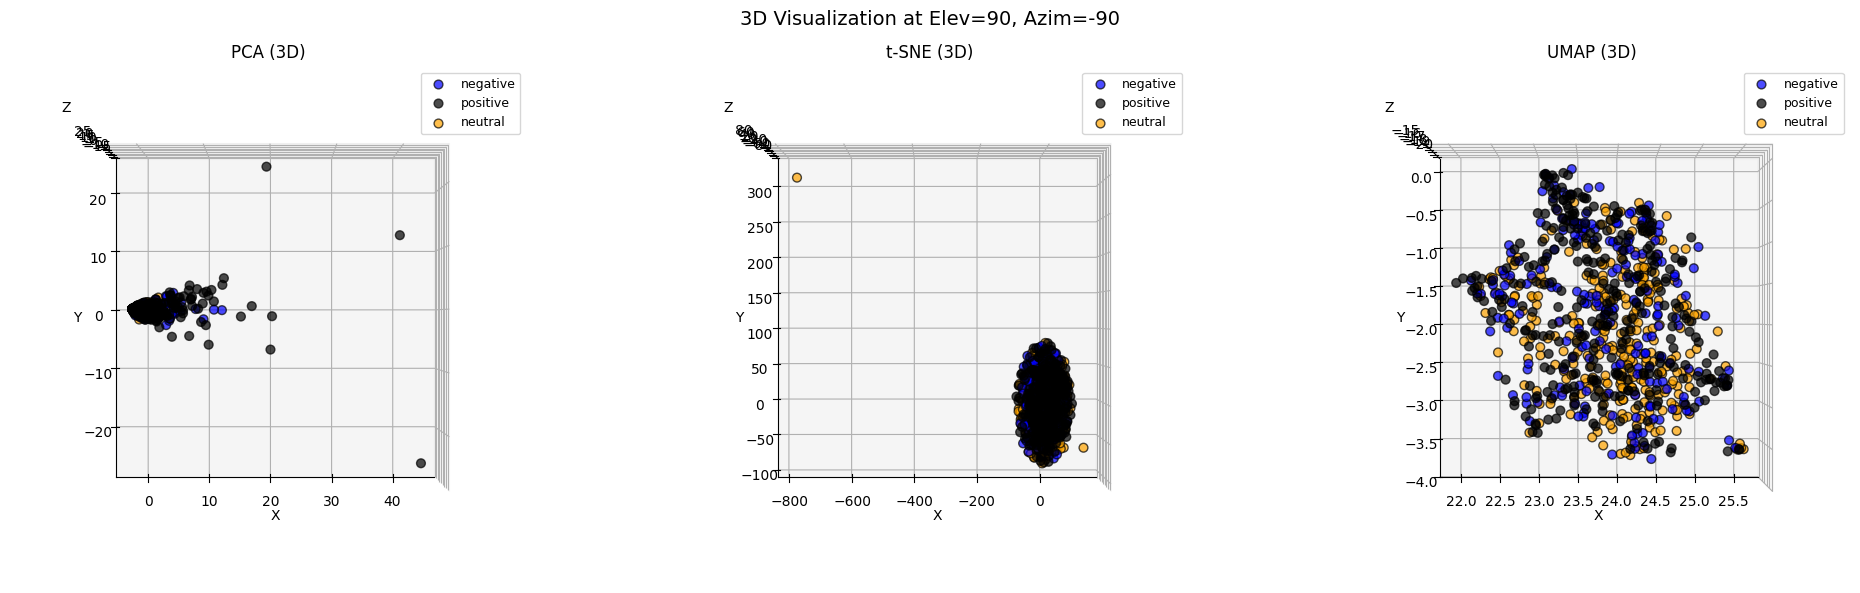

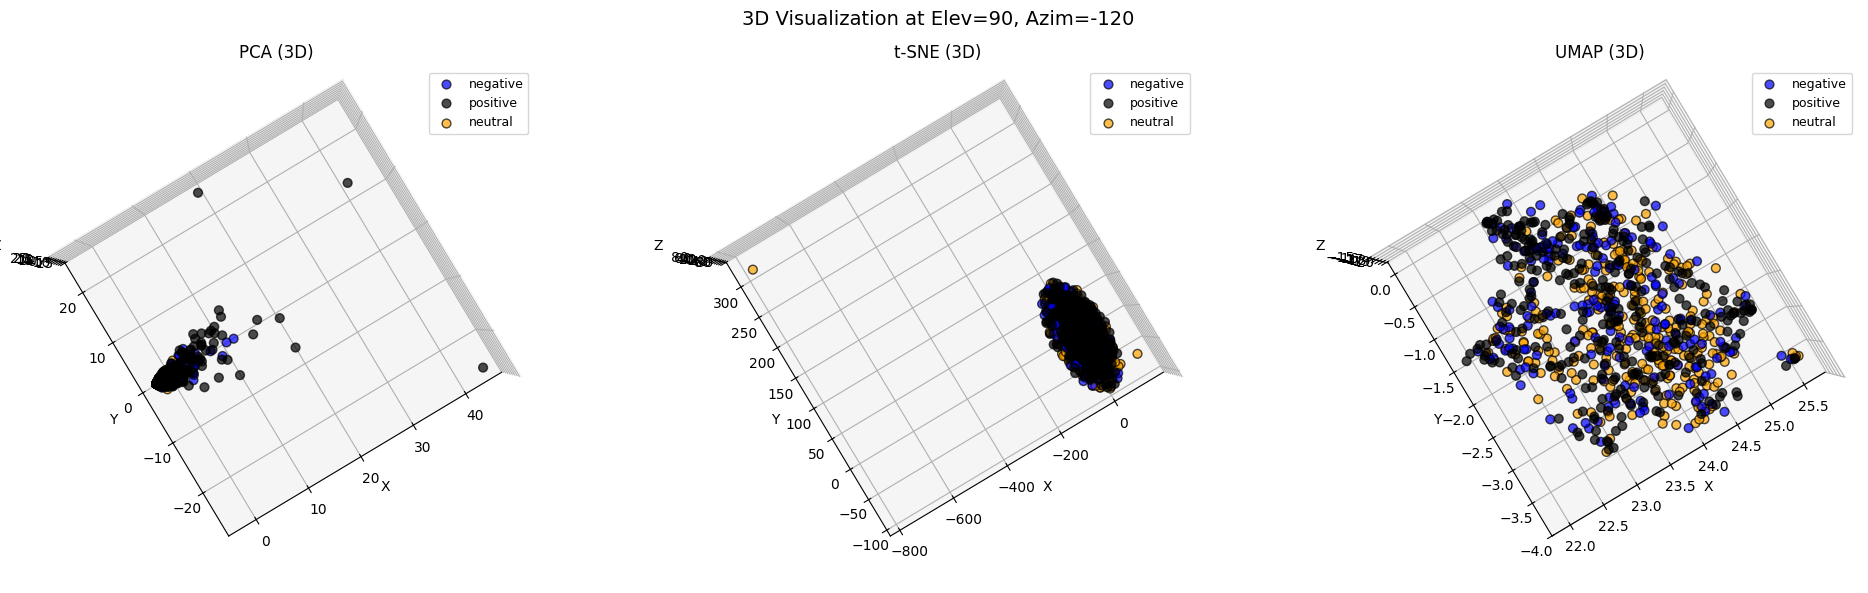

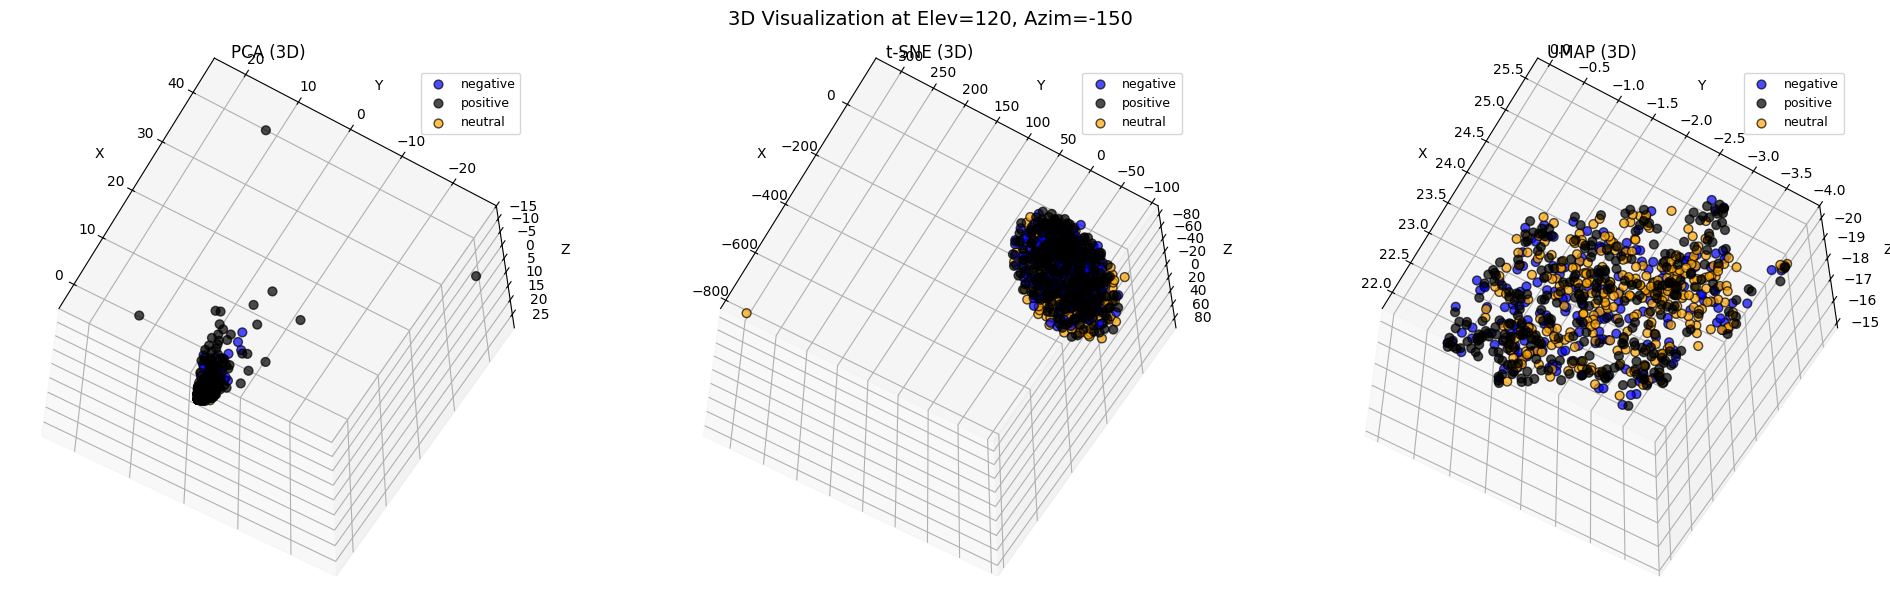

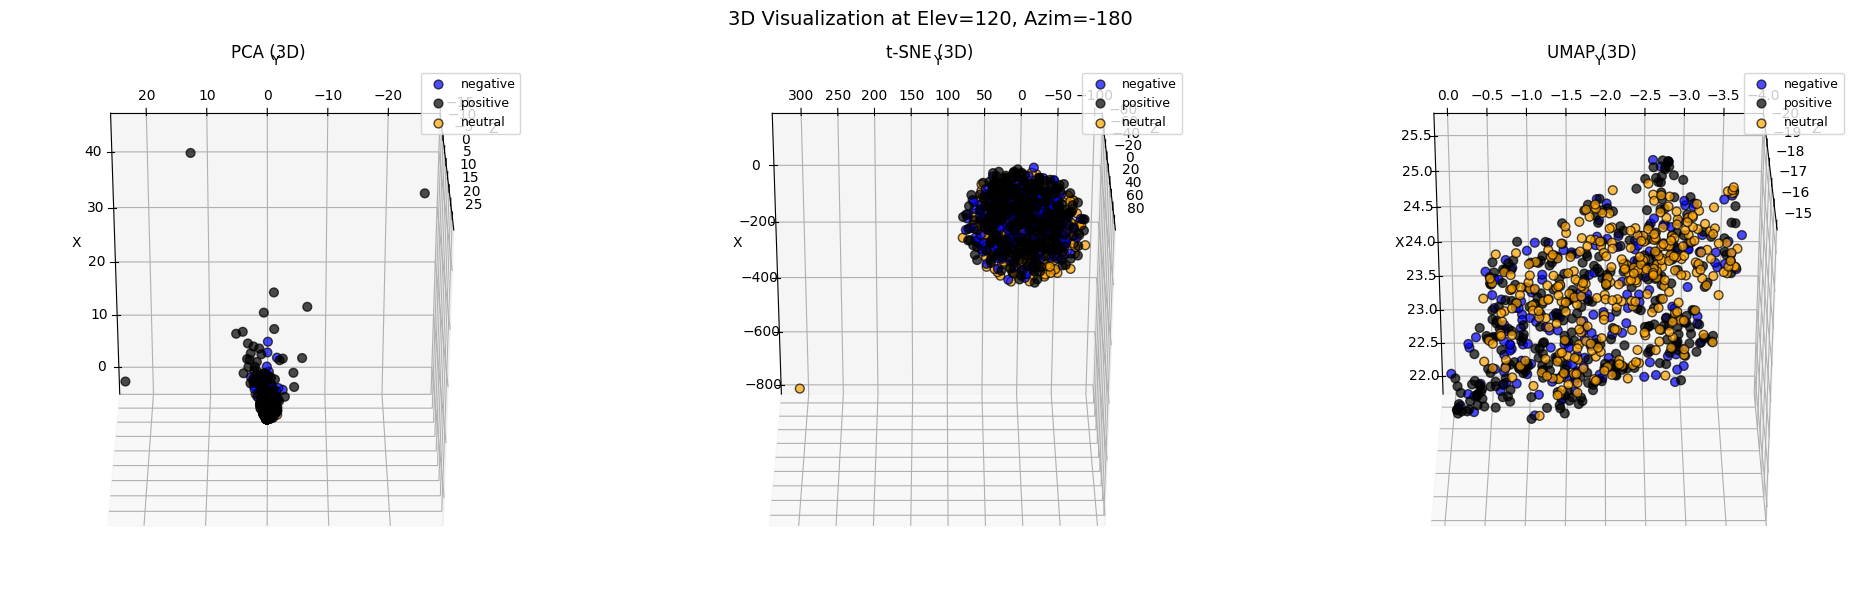

In [280]:
#Answer Here
from mpl_toolkits.mplot3d import Axes3D

# 3D scatter plotting function
def plot_3d_points(ax, reduced_data, method_name, colors, categories, X):
    """Plot 3D data for each category."""
    for color, label in zip(colors, categories):
        # Filter points for this category
        points = reduced_data[X['sentiment_name'] == label].T
        ax.scatter(points[0], points[1], points[2],
                   c=color, label=label, alpha=0.7, marker='o', edgecolor='k', s=40)

    ax.set_title(method_name)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(alpha=0.3, linestyle=':')

# Function to draw 3D comparison plots
def visualize_3d_reductions(pca_data, tsne_data, umap_data, angles, colors, categories, X):
    """Visualize PCA, t-SNE, and UMAP results from multiple viewing angles."""
    for elev, azim in angles:
        fig = plt.figure(figsize=(20, 6))
        
        ax1 = fig.add_subplot(131, projection='3d')
        ax2 = fig.add_subplot(132, projection='3d')
        ax3 = fig.add_subplot(133, projection='3d')

        for ax in [ax1, ax2, ax3]:
            ax.view_init(elev=elev, azim=azim)

        plot_3d_points(ax1, pca_data, "PCA (3D)", colors, categories, X)
        plot_3d_points(ax2, tsne_data, "t-SNE (3D)", colors, categories, X)
        plot_3d_points(ax3, umap_data, "UMAP (3D)", colors, categories, X)

        fig.suptitle(f"3D Visualization at Elev={elev}, Azim={azim}", fontsize=14)
        plt.tight_layout()
        plt.show()

# --- Dimensionality reduction ---
pca_3d = PCA(n_components=3).fit_transform(augmented_df.values)
tsne_3d = TSNE(n_components=3, random_state=42).fit_transform(augmented_df.values)
umap_3d = umap.UMAP(n_components=3, random_state=42).fit_transform(augmented_df.values)

# Example color and angle setup
color_palette = ['blue', 'black', 'orange']  # match to your number of categories
view_angles = [(15, 0), (15, -30), (15, -60), (15, -75),(90, -90), (90, -120), (120, -150), (120, -180)]

# Draw all 3D plots
visualize_3d_reductions(pca_3d, tsne_3d, umap_3d, view_angles, color_palette, categories, X)


**Findings:**

### 5.6 Discretization and Binarization

In [251]:
from sklearn import preprocessing, metrics, decomposition, pipeline, dummy

In [252]:
mlb = preprocessing.LabelBinarizer()

In [253]:
mlb.fit(X.sentiment)

,neg_label,0
,pos_label,1
,sparse_output,False


In [254]:
X['bin_category'] = mlb.transform(X['sentiment']).tolist()

In [255]:
X[0:9]

,text,title,sentiment,subreddit,label,sentiment_name,tokenized_text,bin_category,bin_category_name
0,Calls on retards,Retardation is on the menu boys! WSB is so back,-1.0,wallstreetbets,-1.0,negative,"{on, retards, Calls}","[1, 0, 0]","[1, 0, 0]"
1,Stunt as in like why did they even make a big ...,Retail giant TARGET has now declined for 10 co...,1.0,wallstreetbets,0.0,positive,"{in, first, like, talk, should, a, politics, N...","[0, 0, 1]","[0, 0, 1]"
2,Seeing lots of red in the ticker.,How do you feel about a sitting president maki...,0.0,StockMarket,0.0,neutral,"{red, in, lots, of, the, ticker., Seeing}","[0, 1, 0]","[0, 1, 0]"
3,Vision Marine Technologies Inc. is rewriting t...,Who knows more? $VMAR,1.0,stockstobuytoday,1.0,positive,"{rewriting, unthinkable, your, Marine, like, c...","[0, 0, 1]","[0, 0, 1]"
4,He didn’t say thank you.,The Trump administration is begging Xi Jinping...,0.0,StockMarket,-1.0,neutral,"{He, thank, say, didn’t, you.}","[0, 1, 0]","[0, 1, 0]"
5,"Hoping to ejaculate in wet warm puss tonight, ...",Weekend Discussion Thread for the Weekend of A...,1.0,wallstreetbets,0.0,positive,"{in, to, warm, wet, Hoping, me, luck, ejaculat...","[0, 0, 1]","[0, 0, 1]"
6,Trump will respond to china increasing their t...,Is the market in complete denial right now?,-1.0,stocks,-1.0,negative,"{companies, be, A, fire, is, tariffs., startin...","[1, 0, 0]","[1, 0, 0]"
7,Confirmed not a trap. Its been like this for p...,Retardation is on the menu boys! WSB is so back,1.0,wallstreetbets,0.0,positive,"{like, Confirmed, a, have, just, this, spread,...","[0, 0, 1]","[0, 0, 1]"
8,Am I the only one seeing the cup & handle brea...,"It's fucking awful seeing the ""Silver"" misinfo...",1.0,stocks,1.0,positive,"{cup, &, Day?, Thursday., held, a, line, high?...","[0, 0, 1]","[0, 0, 1]"


**Check if it works on sentiment name**

In [256]:
# Answer here
"""Yes, it does works."""
mlb.fit(X.sentiment_name)
X['bin_category_name'] = mlb.transform(X['sentiment_name']).tolist()
X[0:9]

,text,title,sentiment,subreddit,label,sentiment_name,tokenized_text,bin_category,bin_category_name
0,Calls on retards,Retardation is on the menu boys! WSB is so back,-1.0,wallstreetbets,-1.0,negative,"{on, retards, Calls}","[1, 0, 0]","[1, 0, 0]"
1,Stunt as in like why did they even make a big ...,Retail giant TARGET has now declined for 10 co...,1.0,wallstreetbets,0.0,positive,"{in, first, like, talk, should, a, politics, N...","[0, 0, 1]","[0, 0, 1]"
2,Seeing lots of red in the ticker.,How do you feel about a sitting president maki...,0.0,StockMarket,0.0,neutral,"{red, in, lots, of, the, ticker., Seeing}","[0, 1, 0]","[0, 1, 0]"
3,Vision Marine Technologies Inc. is rewriting t...,Who knows more? $VMAR,1.0,stockstobuytoday,1.0,positive,"{rewriting, unthinkable, your, Marine, like, c...","[0, 0, 1]","[0, 0, 1]"
4,He didn’t say thank you.,The Trump administration is begging Xi Jinping...,0.0,StockMarket,-1.0,neutral,"{He, thank, say, didn’t, you.}","[0, 1, 0]","[0, 1, 0]"
5,"Hoping to ejaculate in wet warm puss tonight, ...",Weekend Discussion Thread for the Weekend of A...,1.0,wallstreetbets,0.0,positive,"{in, to, warm, wet, Hoping, me, luck, ejaculat...","[0, 0, 1]","[0, 0, 1]"
6,Trump will respond to china increasing their t...,Is the market in complete denial right now?,-1.0,stocks,-1.0,negative,"{companies, be, A, fire, is, tariffs., startin...","[1, 0, 0]","[1, 0, 0]"
7,Confirmed not a trap. Its been like this for p...,Retardation is on the menu boys! WSB is so back,1.0,wallstreetbets,0.0,positive,"{like, Confirmed, a, have, just, this, spread,...","[0, 0, 1]","[0, 0, 1]"
8,Am I the only one seeing the cup & handle brea...,"It's fucking awful seeing the ""Silver"" misinfo...",1.0,stocks,1.0,positive,"{cup, &, Day?, Thursday., held, a, line, high?...","[0, 0, 1]","[0, 0, 1]"


# 6. Data Exploration

In [257]:
# We retrieve 3 sentences for a random record
document_to_transform_1 = []
random_record_1 = X.iloc[10]
random_record_1 = random_record_1['text']
document_to_transform_1.append(random_record_1)

document_to_transform_2 = []
random_record_2 = X.iloc[100]
random_record_2 = random_record_2['text']
document_to_transform_2.append(random_record_2)

document_to_transform_3 = []
random_record_3 = X.iloc[200]
random_record_3 = random_record_3['text']
document_to_transform_3.append(random_record_3)

In [258]:
from sklearn.preprocessing import binarize

# Transform sentence with Vectorizers
document_vector_count_1 = count_vect.transform(document_to_transform_1)
document_vector_count_2 = count_vect.transform(document_to_transform_2)
document_vector_count_3 = count_vect.transform(document_to_transform_3)

# Binarize vectors to simplify: 0 for abscence, 1 for prescence
document_vector_count_1_bin = binarize(document_vector_count_1)
document_vector_count_2_bin = binarize(document_vector_count_2)
document_vector_count_3_bin = binarize(document_vector_count_3)

# print vectors
print("Let's take a look at the count vectors:")
print(document_vector_count_1.todense())
print(document_vector_count_2.todense())
print(document_vector_count_3.todense())

Let's take a look at the count vectors:
[[0 0 0 ... 0 0 0]]
[[0 0 0 ... 0 0 0]]
[[0 0 0 ... 0 0 0]]


In [259]:
from sklearn.metrics.pairwise import cosine_similarity

# Calculate Cosine Similarity
cos_sim_count_1_2 = cosine_similarity(document_vector_count_1, document_vector_count_2, dense_output=True)
cos_sim_count_1_3 = cosine_similarity(document_vector_count_1, document_vector_count_3, dense_output=True)
cos_sim_count_2_3 = cosine_similarity(document_vector_count_2, document_vector_count_3, dense_output=True)

cos_sim_count_1_1 = cosine_similarity(document_vector_count_1, document_vector_count_1, dense_output=True)
cos_sim_count_2_2 = cosine_similarity(document_vector_count_2, document_vector_count_2, dense_output=True)
cos_sim_count_3_3 = cosine_similarity(document_vector_count_3, document_vector_count_3, dense_output=True)

# Print 
print("Cosine Similarity using count bw 1 and 2: %(x)f" %{"x":cos_sim_count_1_2})
print("Cosine Similarity using count bw 1 and 3: %(x)f" %{"x":cos_sim_count_1_3})
print("Cosine Similarity using count bw 2 and 3: %(x)f" %{"x":cos_sim_count_2_3})

print("Cosine Similarity using count bw 1 and 1: %(x)f" %{"x":cos_sim_count_1_1})
print("Cosine Similarity using count bw 2 and 2: %(x)f" %{"x":cos_sim_count_2_2})
print("Cosine Similarity using count bw 3 and 3: %(x)f" %{"x":cos_sim_count_3_3})

Cosine Similarity using count bw 1 and 2: 0.000000
Cosine Similarity using count bw 1 and 3: 0.065372
Cosine Similarity using count bw 2 and 3: 0.000000
Cosine Similarity using count bw 1 and 1: 1.000000
Cosine Similarity using count bw 2 and 2: 1.000000
Cosine Similarity using count bw 3 and 3: 1.000000


C:\Users\user\AppData\Local\Temp\ipykernel_2060\452772485.py:13: DeprecationWarning:

Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)

C:\Users\user\AppData\Local\Temp\ipykernel_2060\452772485.py:14: DeprecationWarning:

Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)

C:\Users\user\AppData\Local\Temp\ipykernel_2060\452772485.py:15: DeprecationWarning:

Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)

C:\Users\user\AppData\Local\Temp\ipykernel_2060\452772485.py:17: DeprecationWarning:

Conversion of an array with ndim > 0 to a scalar i

**Change the text refs and see the effect**

In [260]:
#Answer
document_to_transform_3 = []
random_record_3 = X.iloc[15]    # change: 1000 to 500
random_record_3 = random_record_3['text']
document_to_transform_3.append(random_record_3)
document_vector_count_3 = count_vect.transform(document_to_transform_3)
document_vector_count_3_bin = binarize(document_vector_count_3)

# Calculate Cosine Similarity
cos_sim_count_1_2 = cosine_similarity(document_vector_count_1, document_vector_count_2, dense_output=True)
cos_sim_count_1_3 = cosine_similarity(document_vector_count_1, document_vector_count_3, dense_output=True)
cos_sim_count_2_3 = cosine_similarity(document_vector_count_2, document_vector_count_3, dense_output=True)

cos_sim_count_1_1 = cosine_similarity(document_vector_count_1, document_vector_count_1, dense_output=True)
cos_sim_count_2_2 = cosine_similarity(document_vector_count_2, document_vector_count_2, dense_output=True)
cos_sim_count_3_3 = cosine_similarity(document_vector_count_3, document_vector_count_3, dense_output=True)

# Print 
print("Cosine Similarity using count bw 1 and 2: %(x)f" %{"x":cos_sim_count_1_2})
print("Cosine Similarity using count bw 1 and 3: %(x)f" %{"x":cos_sim_count_1_3})
print("Cosine Similarity using count bw 2 and 3: %(x)f" %{"x":cos_sim_count_2_3})

print("Cosine Similarity using count bw 1 and 1: %(x)f" %{"x":cos_sim_count_1_1})
print("Cosine Similarity using count bw 2 and 2: %(x)f" %{"x":cos_sim_count_2_2})
print("Cosine Similarity using count bw 3 and 3: %(x)f" %{"x":cos_sim_count_3_3})

Cosine Similarity using count bw 1 and 2: 0.000000
Cosine Similarity using count bw 1 and 3: 0.000000
Cosine Similarity using count bw 2 and 3: 0.000000
Cosine Similarity using count bw 1 and 1: 1.000000
Cosine Similarity using count bw 2 and 2: 1.000000
Cosine Similarity using count bw 3 and 3: 1.000000


C:\Users\user\AppData\Local\Temp\ipykernel_2060\1926625951.py:19: DeprecationWarning:

Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)

C:\Users\user\AppData\Local\Temp\ipykernel_2060\1926625951.py:20: DeprecationWarning:

Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)

C:\Users\user\AppData\Local\Temp\ipykernel_2060\1926625951.py:21: DeprecationWarning:

Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)

C:\Users\user\AppData\Local\Temp\ipykernel_2060\1926625951.py:23: DeprecationWarning:

Conversion of an array with ndim > 0 to a scal

# 7. Data Classification

**Naive Bayes**

In [261]:
#Model with only the document-term frequency data
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, accuracy_score

# Create a mapping from numerical labels to category names
category_mapping = dict(X[['sentiment', 'sentiment_name']].drop_duplicates().values)

# Convert the numerical category labels to text labels
target_names = [category_mapping[label] for label in sorted(category_mapping.keys())]

# Split the data into training and testing sets (70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(tdm_df, X['sentiment'], test_size=0.3, random_state=42)

In [262]:
# Train the Naive Bayes classifier
nb_classifier = MultinomialNB()
nb_classifier.fit(X_train, y_train)

# Make predictions on the test set
y_pred = nb_classifier.predict(X_test)

# Evaluate the classifier
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=target_names, digits=4))

Accuracy: 0.5120967741935484

Classification Report:
               precision    recall  f1-score   support

    negative     0.4783    0.3607    0.4112        61
     neutral     0.8125    0.2737    0.4094        95
    positive     0.4647    0.8587    0.6031        92

    accuracy                         0.5121       248
   macro avg     0.5852    0.4977    0.4746       248
weighted avg     0.6013    0.5121    0.4817       248



**Use augmented data and see the effect**

In [263]:
#Answer
X_train, X_test, y_train, y_test = train_test_split(augmented_df, X['sentiment'], test_size=0.3, random_state=42)

nb_classifier = MultinomialNB()
nb_classifier.fit(X_train, y_train)

y_pred = nb_classifier.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=target_names, digits=4))

Accuracy: 0.5080645161290323

Classification Report:
               precision    recall  f1-score   support

    negative     0.4211    0.3934    0.4068        61
     neutral     0.7674    0.3474    0.4783        95
    positive     0.4662    0.7500    0.5750        92

    accuracy                         0.5081       248
   macro avg     0.5516    0.4969    0.4867       248
weighted avg     0.5705    0.5081    0.4966       248



**Decision Tree Classifier**

In [264]:
# Decision Tree with only the document-term frequency data
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score

# Split the data (already done above, but shown here for clarity)
X_train, X_test, y_train, y_test = train_test_split(tdm_df, X['sentiment'], test_size=0.3, random_state=42)

# Train Decision Tree
dt_classifier = DecisionTreeClassifier(random_state=42)
dt_classifier.fit(X_train, y_train)

# Predict and evaluate
y_pred_dt = dt_classifier.predict(X_test)
print("Decision Tree Accuracy (TDM):", accuracy_score(y_test, y_pred_dt))
print("\nClassification Report:\n", classification_report(y_test, y_pred_dt, target_names=target_names, digits=4))

Decision Tree Accuracy (TDM): 0.5846774193548387

Classification Report:
               precision    recall  f1-score   support

    negative     0.4068    0.3934    0.4000        61
     neutral     0.6372    0.7579    0.6923        95
    positive     0.6447    0.5326    0.5833        92

    accuracy                         0.5847       248
   macro avg     0.5629    0.5613    0.5585       248
weighted avg     0.5833    0.5847    0.5800       248



**Use augmented data and see the effect**

In [265]:
#Answer
X_train, X_test, y_train, y_test = train_test_split(augmented_df, X['sentiment'], test_size=0.3, random_state=42)

# Train Decision Tree
dt_classifier = DecisionTreeClassifier(random_state=42)
dt_classifier.fit(X_train, y_train)

# Predict and evaluate
y_pred_dt = dt_classifier.predict(X_test)
print("Decision Tree Accuracy (TDM):", accuracy_score(y_test, y_pred_dt))
print("\nClassification Report:\n", classification_report(y_test, y_pred_dt, target_names=target_names, digits=4))

Decision Tree Accuracy (TDM): 0.5403225806451613

Classification Report:
               precision    recall  f1-score   support

    negative     0.3077    0.2623    0.2832        61
     neutral     0.5902    0.7579    0.6636        95
    positive     0.6216    0.5000    0.5542        92

    accuracy                         0.5403       248
   macro avg     0.5065    0.5067    0.5003       248
weighted avg     0.5324    0.5403    0.5295       248



### Observation
**Naive Bayes with original data performs the best classification**

**The neutral sentiment performs the best among all and it has a significant leap of accuray**

This may result from the followings:
- Violation of Naive Bayes' independence assumption
- Noisy or Non-discriminative patterns
- Curse of dimentionality
- Class imbalance patterns
    

## Third part of phase 2

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf_vect = TfidfVectorizer()
X_tfidf = tfidf_vect.fit_transform(X['text'])  # sparse matrix

# Word frequency feature classifier
X_train, X_test, y_train, y_test = train_test_split(X_counts, X['sentiment'], test_size=0.3, random_state=42)

nb_classifier = MultinomialNB()
nb_classifier.fit(X_train, y_train)

y_pred = nb_classifier.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=target_names, digits=4))

# TF-IDF feature classifier 
X_train, X_test, y_train, y_test = train_test_split(X_tfidf, X['sentiment'], test_size=0.3, random_state=42)

nb_classifier = MultinomialNB()
nb_classifier.fit(X_train, y_train)

y_pred = nb_classifier.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=target_names, digits=4))
    

Accuracy: 0.5120967741935484

Classification Report:
               precision    recall  f1-score   support

    negative     0.4783    0.3607    0.4112        61
     neutral     0.8125    0.2737    0.4094        95
    positive     0.4647    0.8587    0.6031        92

    accuracy                         0.5121       248
   macro avg     0.5852    0.4977    0.4746       248
weighted avg     0.6013    0.5121    0.4817       248

Accuracy: 0.4717741935483871

Classification Report:
               precision    recall  f1-score   support

    negative     1.0000    0.0164    0.0323        61
     neutral     0.7500    0.3158    0.4444        95
    positive     0.4155    0.9348    0.5753        92

    accuracy                         0.4718       248
   macro avg     0.7218    0.4223    0.3507       248
weighted avg     0.6874    0.4718    0.3916       248



In [302]:
weight = X_tfidf.toarray()
print(weight.shape)
print(X_tfidf[0])
print(weight[0])

(824, 4346)
<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 3 stored elements and shape (1, 4346)>
  Coords	Values
  (0, 692)	0.5962817918231856
  (0, 2706)	0.32793677993357806
  (0, 3248)	0.7327383524198299
[0. 0. 0. ... 0. 0. 0.]


**Using different Naive Bayes methods**

In [320]:
from sklearn.naive_bayes import BernoulliNB
from sklearn.naive_bayes import GaussianNB

# BernoulliNB
'''Consider the TF-IDF value that is greater than 0.05 as 1'''
X_train, X_test, y_train, y_test = train_test_split(X_tfidf, X['sentiment'], test_size=0.3, random_state=42)
X_train_bin = (X_train > 0.05).astype(int)
X_test_bin = (X_test > 0.05).astype(int)
nb_classifier = BernoulliNB()
nb_classifier.fit(X_train_bin, y_train)

y_pred = nb_classifier.predict(X_test_bin)

print("BernoulliNB")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=target_names, digits=4))


# GaussianNB
X_train_Gaussian = X_train.toarray()
X_test_Gaussian = X_test.toarray()
nb_classifier = GaussianNB()
nb_classifier.fit(X_train_Gaussian, y_train)

y_pred = nb_classifier.predict(X_test_Gaussian)
print("-----------------------------------------------------")
print("\nGuassianNB")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=target_names, digits=4))

BernoulliNB
Accuracy: 0.5161290322580645

Classification Report:
               precision    recall  f1-score   support

    negative     0.4444    0.0656    0.1143        61
     neutral     0.4845    0.9895    0.6505        95
    positive     0.6667    0.3261    0.4380        92

    accuracy                         0.5161       248
   macro avg     0.5319    0.4604    0.4009       248
weighted avg     0.5422    0.5161    0.4398       248

-----------------------------------------------------

GuassianNB
Accuracy: 0.5241935483870968

Classification Report:
               precision    recall  f1-score   support

    negative     0.3519    0.3115    0.3304        61
     neutral     0.8298    0.4105    0.5493        95
    positive     0.4898    0.7826    0.6025        92

    accuracy                         0.5242       248
   macro avg     0.5571    0.5015    0.4941       248
weighted avg     0.5861    0.5242    0.5152       248



**Using augmentation with feature patterns**

In [325]:
terms = tfidf_vect.get_feature_names_out()
tdm_df = pd.DataFrame(X_tfidf.toarray(), columns=terms, index=X.index)
# Concatenate the original TDM and the pattern matrix to augment the features
augmented_df = pd.concat([tdm_df, pattern_matrix], axis=1)

X_train, X_test, y_train, y_test = train_test_split(augmented_df, X['sentiment'], test_size=0.3, random_state=42)

nb_classifier = MultinomialNB()
nb_classifier.fit(X_train, y_train)

y_pred = nb_classifier.predict(X_test)
print("\nMultinomialNB")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=target_names, digits=4))

X_train_bin = (X_train > 0.05).astype(int)
X_test_bin = (X_test > 0.05).astype(int)
nb_classifier = BernoulliNB()
nb_classifier.fit(X_train_bin, y_train)

y_pred = nb_classifier.predict(X_test_bin)
print("-----------------------------------------------------")
print("\nBernoulliNB")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=target_names, digits=4))


# GaussianNB
X_train_Gaussian = X_train.values  
X_test_Gaussian = X_test.values
nb_classifier = GaussianNB()
nb_classifier.fit(X_train_Gaussian, y_train)

y_pred = nb_classifier.predict(X_test_Gaussian)
print("-----------------------------------------------------")
print("\nGuassianNB")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=target_names, digits=4))


MultinomialNB
Accuracy: 0.5241935483870968

Classification Report:
               precision    recall  f1-score   support

    negative     0.5833    0.1148    0.1918        61
     neutral     0.6714    0.4947    0.5697        95
    positive     0.4578    0.8261    0.5891        92

    accuracy                         0.5242       248
   macro avg     0.5709    0.4785    0.4502       248
weighted avg     0.5705    0.5242    0.4840       248

-----------------------------------------------------

BernoulliNB
Accuracy: 0.5120967741935484

Classification Report:
               precision    recall  f1-score   support

    negative     0.3750    0.0492    0.0870        61
     neutral     0.4819    0.9789    0.6458        95
    positive     0.6596    0.3370    0.4460        92

    accuracy                         0.5121       248
   macro avg     0.5055    0.4550    0.3929       248
weighted avg     0.5215    0.5121    0.4343       248

------------------------------------------------

### Insights
1. **Effect of pattern augmentation**
    - **MultinomialNB:** Significant improvement in accuracy (+5.2%) and weighted F1.

        - Negative and neutral classes benefit most.

        - Positive class slightly drops in recall but becomes more balanced.
    - **GaussianNB:** Slight improvement (~1.2% accuracy) due to dense features being better handled.
    - **BernoulliNB** Small decrease in performance; binary features may not benefit from extra sparse patterns.
2. **Class imbalance still remains an issue**
    - Negative class is underrepresented; even with augmentation, recall remains lower than neutral/positive.

3. **Classifier selection**
    
    - **Original TF-IDF:** GaussianNB slightly outperforms others, especially for positive class.
    
    - **Pattern augmented TF-IDF:** MultinomialNB catches up and performs more balanced predictions.
    
    - BernoulliNB is less sensitive to pattern augmentation and heavily favors neutral class.
4. **Trade-offs**
    
    - Pattern features can slightly reduce precision in dominant classes (positive) but improve detection of minority classes.

    - Overall effect is more balanced performance across classes rather than maximum accuracy.

## Fourth part of phase 2